# Fat-Tail and Filtered VaR Models

This notebook extends the market-risk engine by incorporating non-normal
return distributions and time-varying volatility.

The models implemented are:

- Student-t Parametric VaR
- EWMA Student-t VaR
- Filtered Historical Simulation
- Rolling statistical backtesting
- Parameter-sensitivity analysis

The purpose is to determine whether heavier tails and volatility filtering
improve the calibration of the Day 1 and Day 2 risk models.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.special import xlogy
from scipy.stats import (
    chi2,
    jarque_bera,
    kurtosis,
    norm,
    skew,
    t,
)

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
CHARTS_DIR = PROJECT_ROOT / "outputs" / "charts"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\Pranav\Desktop\market-risk-engine


In [2]:
returns_path = PROCESSED_DATA_DIR / "daily_returns.csv"
pnl_path = PROCESSED_DATA_DIR / "daily_pnl.csv"

if not returns_path.exists():
    raise FileNotFoundError(
        "daily_returns.csv was not found. Run the Day 1 notebook first."
    )

if not pnl_path.exists():
    raise FileNotFoundError(
        "daily_pnl.csv was not found. Run the Day 1 notebook first."
    )

returns = pd.read_csv(
    returns_path,
    index_col="date",
    parse_dates=True,
).sort_index()

pnl_data = pd.read_csv(
    pnl_path,
    index_col="date",
    parse_dates=True,
).sort_index()

portfolio_pnl = pnl_data["portfolio_pnl_eur"].copy()

print(f"Return observations: {len(returns):,}")
print(f"P&L observations: {len(portfolio_pnl):,}")
print(
    f"Sample: {portfolio_pnl.index.min().date()} to "
    f"{portfolio_pnl.index.max().date()}"
)

display(returns.head())
display(pnl_data.head())

Return observations: 2,654
P&L observations: 2,654
Sample: 2016-01-05 to 2026-07-31


,Equity index,Government bond proxy,EUR/USD,Gold
date,,,,
2016-01-05,0.001691,-0.004035,-0.002436,0.002819
2016-01-06,-0.012614,0.013476,-0.006978,0.014441
2016-01-07,-0.023992,0.001795,0.002512,0.014140
2016-01-08,-0.010976,0.004478,0.013636,-0.004428
2016-01-11,0.000990,-0.010943,0.001379,-0.008895


,Equity index_pnl_eur,Government bond proxy_pnl_eur,EUR/USD_pnl_eur,Gold_pnl_eur,portfolio_pnl_eur
date,,,,,
2016-01-05,422.838435,-1210.471878,-487.227441,422.782949,-852.077936
2016-01-06,-3153.540592,4042.717303,-1395.625824,2166.114353,1659.665240
2016-01-07,-5998.008910,538.490434,502.315779,2120.956410,-2836.246287
2016-01-08,-2744.048204,1343.400326,2727.116186,-664.156214,662.312094
2016-01-11,247.484229,-3283.004797,275.711638,-1334.219964,-4094.028895


In [3]:
assert not returns.empty
assert not pnl_data.empty

assert returns.index.equals(pnl_data.index)
assert returns.index.is_monotonic_increasing
assert pnl_data.index.is_monotonic_increasing

assert not returns.index.duplicated().any()
assert not pnl_data.index.duplicated().any()

assert not returns.isna().any().any()
assert not pnl_data.isna().any().any()

assert np.isfinite(returns.to_numpy()).all()
assert np.isfinite(pnl_data.to_numpy()).all()

print("Day 3 data loaded and validated successfully.")

Day 3 data loaded and validated successfully.


## 1. Model configuration

The main specifications use:

- One-day holding period
- 99% confidence level
- 250-day rolling estimation window
- Zero expected one-day portfolio P&L
- EUR 900,000 gross exposure
- One-day-ahead out-of-sample forecasts

The zero-mean assumption is retained for consistency with the Day 1 and Day 2
Parametric Normal models. Daily expected return is generally small relative
to daily volatility and is difficult to estimate reliably over short windows.

In [4]:
CONFIDENCE_LEVEL = 0.99
TAIL_PROBABILITY = 1 - CONFIDENCE_LEVEL
LOOKBACK_WINDOW = 250

EWMA_LAMBDA = 0.94

NOTIONALS = pd.Series(
    {
        "Equity index": 250_000,
        "Government bond proxy": 300_000,
        "EUR/USD": 200_000,
        "Gold": 150_000,
    },
    dtype=float,
)

assert list(NOTIONALS.index) == list(returns.columns)
assert NOTIONALS.sum() == 900_000

print(f"Confidence level: {CONFIDENCE_LEVEL:.0%}")
print(f"Tail probability: {TAIL_PROBABILITY:.0%}")
print(f"Lookback window: {LOOKBACK_WINDOW} days")
print(f"EWMA lambda: {EWMA_LAMBDA}")
print(f"Gross exposure: EUR {NOTIONALS.sum():,.0f}")

Confidence level: 99%
Tail probability: 1%
Lookback window: 250 days
EWMA lambda: 0.94
Gross exposure: EUR 900,000


## 2. Portfolio P&L distribution diagnostics

A normal distribution is symmetric and has zero excess kurtosis.

Negative skewness indicates that large losses are more pronounced than large
gains. Positive excess kurtosis indicates that extreme observations occur
more frequently than predicted by a normal distribution.

The Jarque–Bera test evaluates whether the sample's skewness and kurtosis are
consistent with normality.

In [5]:
recent_portfolio_pnl = portfolio_pnl.iloc[
    -LOOKBACK_WINDOW:
]

full_sample_jb = jarque_bera(portfolio_pnl)
recent_sample_jb = jarque_bera(recent_portfolio_pnl)

distribution_diagnostics = pd.DataFrame(
    {
        "sample": [
            "Full sample",
            "Most recent 250 days",
        ],
        "observations": [
            len(portfolio_pnl),
            len(recent_portfolio_pnl),
        ],
        "mean_eur": [
            portfolio_pnl.mean(),
            recent_portfolio_pnl.mean(),
        ],
        "volatility_eur": [
            portfolio_pnl.std(ddof=1),
            recent_portfolio_pnl.std(ddof=1),
        ],
        "skewness": [
            skew(
                portfolio_pnl,
                bias=False,
            ),
            skew(
                recent_portfolio_pnl,
                bias=False,
            ),
        ],
        "excess_kurtosis": [
            kurtosis(
                portfolio_pnl,
                fisher=True,
                bias=False,
            ),
            kurtosis(
                recent_portfolio_pnl,
                fisher=True,
                bias=False,
            ),
        ],
        "jarque_bera_statistic": [
            full_sample_jb.statistic,
            recent_sample_jb.statistic,
        ],
        "jarque_bera_p_value": [
            full_sample_jb.pvalue,
            recent_sample_jb.pvalue,
        ],
        "reject_normality_at_5_percent": [
            full_sample_jb.pvalue < 0.05,
            recent_sample_jb.pvalue < 0.05,
        ],
    }
)

display(
    distribution_diagnostics.style.format(
        {
            "mean_eur": "EUR {:,.2f}",
            "volatility_eur": "EUR {:,.2f}",
            "skewness": "{:.4f}",
            "excess_kurtosis": "{:.4f}",
            "jarque_bera_statistic": "{:,.4f}",
            "jarque_bera_p_value": "{:.8f}",
        }
    )
)

,sample,observations,mean_eur,volatility_eur,skewness,excess_kurtosis,jarque_bera_statistic,jarque_bera_p_value,reject_normality_at_5_percent
0,Full sample,2654,EUR 244.59,"EUR 4,417.58",-0.2486,6.0924,"4,113.4361",0.00000000,True
1,Most recent 250 days,250,EUR 320.83,"EUR 4,598.94",-0.4283,1.3300,24.6077,0.00000453,True


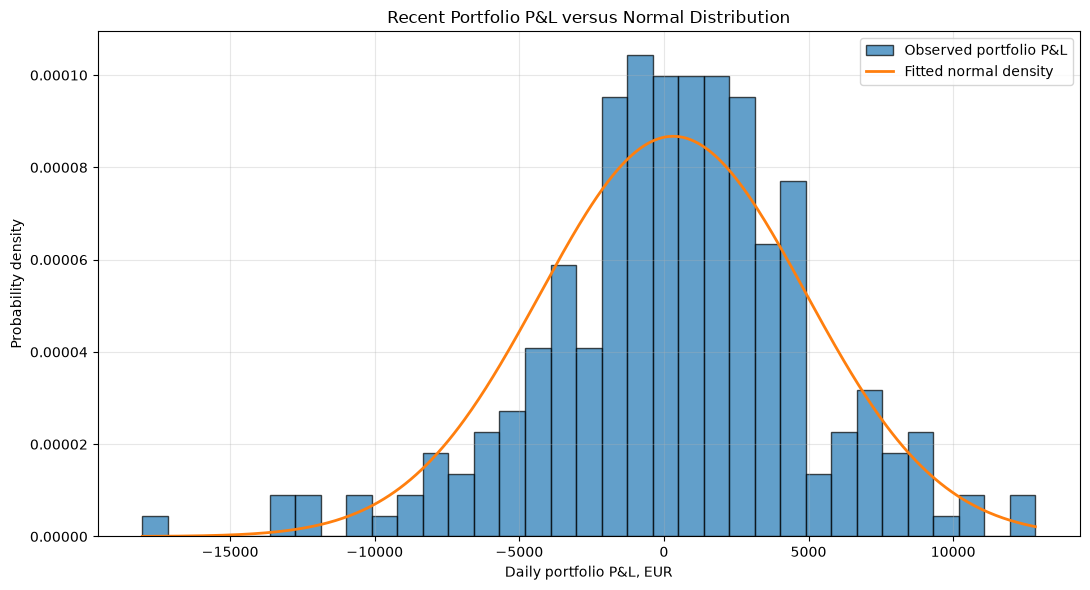

In [6]:
recent_mean = recent_portfolio_pnl.mean()
recent_volatility = recent_portfolio_pnl.std(ddof=1)

pnl_grid = np.linspace(
    recent_portfolio_pnl.min(),
    recent_portfolio_pnl.max(),
    500,
)

normal_density = norm.pdf(
    pnl_grid,
    loc=recent_mean,
    scale=recent_volatility,
)

fig_pnl_normal, ax = plt.subplots(figsize=(11, 6))

ax.hist(
    recent_portfolio_pnl,
    bins=35,
    density=True,
    edgecolor="black",
    alpha=0.7,
    label="Observed portfolio P&L",
)

ax.plot(
    pnl_grid,
    normal_density,
    linewidth=2,
    label="Fitted normal density",
)

ax.set_title(
    "Recent Portfolio P&L versus Normal Distribution"
)
ax.set_xlabel("Daily portfolio P&L, EUR")
ax.set_ylabel("Probability density")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Student-t Parametric VaR

The Student-t distribution assigns more probability to extreme observations
than the normal distribution.

Portfolio P&L is modelled as:

\[
P\&L_t = s z_t,
\qquad
z_t \sim t_{\nu},
\]

where:

- \(s\) is the fitted scale parameter
- \(\nu\) is the degrees-of-freedom parameter
- lower values of \(\nu\) indicate heavier tails

As \(\nu\) becomes large, the Student-t distribution approaches the normal
distribution.

In [7]:
student_t_df, student_t_location, student_t_scale = t.fit(
    recent_portfolio_pnl.to_numpy(dtype=float),
    floc=0.0,
)

if student_t_df <= 1:
    raise RuntimeError(
        "The fitted Student-t distribution has no finite expected shortfall."
    )

student_t_quantile = t.ppf(
    TAIL_PROBABILITY,
    df=student_t_df,
)

student_t_var_eur = -(
    student_t_location
    + student_t_scale * student_t_quantile
)

student_t_tail_density = t.pdf(
    student_t_quantile,
    df=student_t_df,
)

student_t_es_eur = (
    -student_t_location
    + student_t_scale
    * (
        student_t_df
        + student_t_quantile**2
    )
    / (
        student_t_df - 1
    )
    * student_t_tail_density
    / TAIL_PROBABILITY
)

student_t_current_results = pd.DataFrame(
    {
        "model": ["Student-t Parametric"],
        "confidence_level": [CONFIDENCE_LEVEL],
        "lookback": [LOOKBACK_WINDOW],
        "degrees_of_freedom": [student_t_df],
        "location_eur": [student_t_location],
        "scale_eur": [student_t_scale],
        "var_eur": [student_t_var_eur],
        "expected_shortfall_eur": [student_t_es_eur],
    }
)

assert student_t_var_eur > 0
assert student_t_es_eur >= student_t_var_eur

display(
    student_t_current_results.style.format(
        {
            "confidence_level": "{:.0%}",
            "degrees_of_freedom": "{:.3f}",
            "location_eur": "EUR {:,.2f}",
            "scale_eur": "EUR {:,.2f}",
            "var_eur": "EUR {:,.2f}",
            "expected_shortfall_eur": "EUR {:,.2f}",
        }
    )
)

,model,confidence_level,lookback,degrees_of_freedom,location_eur,scale_eur,var_eur,expected_shortfall_eur
0,Student-t Parametric,99%,250,5.583,EUR 0.00,"EUR 3,745.03","EUR 12,069.50","EUR 15,660.26"


In [8]:
normal_volatility = recent_portfolio_pnl.std(ddof=1)

normal_var_eur = (
    norm.ppf(CONFIDENCE_LEVEL)
    * normal_volatility
)

normal_es_eur = (
    normal_volatility
    * norm.pdf(norm.ppf(CONFIDENCE_LEVEL))
    / TAIL_PROBABILITY
)

student_t_vs_normal = pd.DataFrame(
    {
        "model": [
            "Parametric Normal",
            "Student-t Parametric",
        ],
        "var_eur": [
            normal_var_eur,
            student_t_var_eur,
        ],
        "expected_shortfall_eur": [
            normal_es_eur,
            student_t_es_eur,
        ],
    }
)

student_t_vs_normal["var_difference_vs_normal_eur"] = (
    student_t_vs_normal["var_eur"]
    - normal_var_eur
)

student_t_vs_normal["es_difference_vs_normal_eur"] = (
    student_t_vs_normal["expected_shortfall_eur"]
    - normal_es_eur
)

display(
    student_t_vs_normal.style.format(
        {
            "var_eur": "EUR {:,.2f}",
            "expected_shortfall_eur": "EUR {:,.2f}",
            "var_difference_vs_normal_eur": "EUR {:+,.2f}",
            "es_difference_vs_normal_eur": "EUR {:+,.2f}",
        }
    )
)

,model,var_eur,expected_shortfall_eur,var_difference_vs_normal_eur,es_difference_vs_normal_eur
0,Parametric Normal,"EUR 10,698.74","EUR 12,257.16",EUR +0.00,EUR +0.00
1,Student-t Parametric,"EUR 12,069.50","EUR 15,660.26","EUR +1,370.76","EUR +3,403.10"


### Student-t distribution interpretation

Normality is rejected for both the full portfolio P&L sample and the most
recent 250-day window.

The full sample has excess kurtosis of approximately 6.09, indicating a
substantially higher frequency of extreme observations than implied by a
normal distribution. The recent window also remains non-normal, with excess
kurtosis of approximately 1.33 and negative skewness of approximately -0.43.

The fitted Student-t distribution has approximately 5.58 degrees of freedom.
This is consistent with materially heavier tails than the normal distribution.

The Student-t specification increases current 99% VaR by approximately
EUR 1,371, or 12.8%, relative to Parametric Normal VaR. Expected Shortfall
increases by approximately EUR 3,403, or 27.8%.

The larger increase in Expected Shortfall shows that the normality assumption
particularly understates the severity of losses beyond the VaR threshold.

The Student-t distribution remains symmetric, however, and therefore does not
directly represent the observed negative skewness. Filtered Historical
Simulation will later retain this empirical asymmetry.

In [9]:
def calculate_student_t_var_es(
    pnl_series: pd.Series,
    confidence_level: float,
) -> dict:
    """
    Fit a zero-location Student-t distribution and calculate VaR and ES.

    Parameters
    ----------
    pnl_series:
        Historical portfolio P&L observations.
    confidence_level:
        VaR confidence level, such as 0.99.

    Returns
    -------
    dict
        Fitted parameters, VaR and Expected Shortfall.
    """
    if not 0 < confidence_level < 1:
        raise ValueError(
            "confidence_level must lie between zero and one."
        )

    clean_pnl = (
        pd.Series(pnl_series)
        .dropna()
        .astype(float)
    )

    if len(clean_pnl) < 30:
        raise ValueError(
            "At least 30 observations are required."
        )

    if not np.isfinite(clean_pnl.to_numpy()).all():
        raise ValueError(
            "pnl_series contains non-finite values."
        )

    fitted_df, fitted_location, fitted_scale = t.fit(
        clean_pnl.to_numpy(dtype=float),
        floc=0.0,
    )

    if not np.isfinite(fitted_df):
        raise RuntimeError(
            "The fitted degrees of freedom are not finite."
        )

    if fitted_df <= 1:
        raise RuntimeError(
            "The fitted distribution has no finite Expected Shortfall."
        )

    if not np.isfinite(fitted_scale) or fitted_scale <= 0:
        raise RuntimeError(
            "The fitted Student-t scale is invalid."
        )

    tail_probability = 1 - confidence_level

    tail_quantile = t.ppf(
        tail_probability,
        df=fitted_df,
    )

    var_eur = -(
        fitted_location
        + fitted_scale * tail_quantile
    )

    tail_density = t.pdf(
        tail_quantile,
        df=fitted_df,
    )

    expected_shortfall_eur = (
        -fitted_location
        + fitted_scale
        * (
            fitted_df + tail_quantile**2
        )
        / (
            fitted_df - 1
        )
        * tail_density
        / tail_probability
    )

    if var_eur <= 0:
        raise RuntimeError(
            "The calculated VaR is not positive."
        )

    if expected_shortfall_eur < var_eur - 1e-8:
        raise RuntimeError(
            "Expected Shortfall is below VaR."
        )

    return {
        "degrees_of_freedom": float(fitted_df),
        "location_eur": float(fitted_location),
        "scale_eur": float(fitted_scale),
        "var_eur": float(var_eur),
        "expected_shortfall_eur": float(
            expected_shortfall_eur
        ),
    }

In [10]:
student_t_function_check = calculate_student_t_var_es(
    pnl_series=recent_portfolio_pnl,
    confidence_level=CONFIDENCE_LEVEL,
)

display(
    pd.DataFrame([student_t_function_check]).style.format(
        {
            "degrees_of_freedom": "{:.3f}",
            "location_eur": "EUR {:,.2f}",
            "scale_eur": "EUR {:,.2f}",
            "var_eur": "EUR {:,.2f}",
            "expected_shortfall_eur": "EUR {:,.2f}",
        }
    )
)

,degrees_of_freedom,location_eur,scale_eur,var_eur,expected_shortfall_eur
0,5.583,EUR 0.00,"EUR 3,745.03","EUR 12,069.50","EUR 15,660.26"


### 3.1 Rolling Student-t backtest

For each forecast date, the Student-t distribution is fitted using only the
preceding 250 portfolio P&L observations.

The location parameter is fixed at zero, while the scale and degrees of
freedom are re-estimated for every forecast. The realised P&L on the forecast
date is excluded from the estimation window, preventing look-ahead bias.

This allows the estimated tail thickness to change through time.

In [11]:
rolling_student_t_records = []

number_of_forecasts = (
    len(portfolio_pnl) - LOOKBACK_WINDOW
)

for observation_number in range(
    LOOKBACK_WINDOW,
    len(portfolio_pnl),
):
    forecast_number = (
        observation_number
        - LOOKBACK_WINDOW
        + 1
    )

    forecast_date = portfolio_pnl.index[
        observation_number
    ]

    estimation_sample = portfolio_pnl.iloc[
        observation_number - LOOKBACK_WINDOW:
        observation_number
    ]

    try:
        forecast_result = (
            calculate_student_t_var_es(
                pnl_series=estimation_sample,
                confidence_level=CONFIDENCE_LEVEL,
            )
        )
    except Exception as error:
        raise RuntimeError(
            f"Student-t estimation failed for "
            f"{forecast_date.date()}."
        ) from error

    actual_pnl = float(
        portfolio_pnl.iloc[observation_number]
    )

    forecast_var = forecast_result["var_eur"]

    exception = actual_pnl < -forecast_var

    rolling_student_t_records.append(
        {
            "date": forecast_date,
            "actual_pnl_eur": actual_pnl,
            "student_t_degrees_of_freedom": (
                forecast_result[
                    "degrees_of_freedom"
                ]
            ),
            "student_t_scale_eur": (
                forecast_result["scale_eur"]
            ),
            "student_t_var_eur": forecast_var,
            "student_t_es_eur": (
                forecast_result[
                    "expected_shortfall_eur"
                ]
            ),
            "student_t_exception": exception,
        }
    )

    if (
        forecast_number % 500 == 0
        or forecast_number == number_of_forecasts
    ):
        print(
            f"Completed {forecast_number:,} of "
            f"{number_of_forecasts:,} forecasts."
        )

student_t_backtest_results = (
    pd.DataFrame(rolling_student_t_records)
    .set_index("date")
)

print(
    f"Student-t forecasts completed: "
    f"{len(student_t_backtest_results):,}"
)

display(student_t_backtest_results.head())

Completed 500 of 2,404 forecasts.
Completed 1,000 of 2,404 forecasts.
Completed 1,500 of 2,404 forecasts.
Completed 2,000 of 2,404 forecasts.
Completed 2,404 of 2,404 forecasts.
Student-t forecasts completed: 2,404


,actual_pnl_eur,student_t_degrees_of_freedom,student_t_scale_eur,student_t_var_eur,student_t_es_eur,student_t_exception
date,,,,,,
2016-12-30,1654.611656,8.533029,2946.172834,8408.002984,10361.787376,False
2017-01-03,2194.106621,8.625057,2951.536978,8403.472860,10346.450115,False
2017-01-04,2403.266442,8.707896,2956.441172,8399.973165,10333.580557,False
2017-01-05,8378.931018,8.634969,2951.861391,8402.289267,10343.957558,False
2017-01-06,-965.687886,8.570757,2986.193957,8513.927737,10488.242970,False


In [12]:
assert (
    len(student_t_backtest_results)
    == len(portfolio_pnl) - LOOKBACK_WINDOW
)

assert (
    student_t_backtest_results
    .index
    .is_monotonic_increasing
)

assert not (
    student_t_backtest_results
    .isna()
    .any()
    .any()
)

assert (
    student_t_backtest_results[
        "student_t_degrees_of_freedom"
    ] > 1
).all()

assert (
    student_t_backtest_results[
        "student_t_var_eur"
    ] > 0
).all()

assert np.all(
    student_t_backtest_results[
        "student_t_es_eur"
    ]
    >= student_t_backtest_results[
        "student_t_var_eur"
    ] - 1e-8
)

print("Rolling Student-t results validated successfully.")

Rolling Student-t results validated successfully.


In [13]:
student_t_parameter_summary = pd.DataFrame(
    {
        "statistic": [
            "Minimum",
            "25th percentile",
            "Median",
            "75th percentile",
            "Maximum",
        ],
        "degrees_of_freedom": [
            student_t_backtest_results[
                "student_t_degrees_of_freedom"
            ].min(),
            student_t_backtest_results[
                "student_t_degrees_of_freedom"
            ].quantile(0.25),
            student_t_backtest_results[
                "student_t_degrees_of_freedom"
            ].median(),
            student_t_backtest_results[
                "student_t_degrees_of_freedom"
            ].quantile(0.75),
            student_t_backtest_results[
                "student_t_degrees_of_freedom"
            ].max(),
        ],
        "scale_eur": [
            student_t_backtest_results[
                "student_t_scale_eur"
            ].min(),
            student_t_backtest_results[
                "student_t_scale_eur"
            ].quantile(0.25),
            student_t_backtest_results[
                "student_t_scale_eur"
            ].median(),
            student_t_backtest_results[
                "student_t_scale_eur"
            ].quantile(0.75),
            student_t_backtest_results[
                "student_t_scale_eur"
            ].max(),
        ],
    }
)

display(
    student_t_parameter_summary.style.format(
        {
            "degrees_of_freedom": "{:,.3f}",
            "scale_eur": "EUR {:,.2f}",
        }
    )
)

,statistic,degrees_of_freedom,scale_eur
0,Minimum,2.353,"EUR 2,462.01"
1,25th percentile,6.422,"EUR 2,826.66"
2,Median,9.811,"EUR 3,293.31"
3,75th percentile,15.335,"EUR 4,083.78"
4,Maximum,"8,107,632,576,146.369","EUR 6,066.85"


In [14]:
student_t_observations = len(
    student_t_backtest_results
)

student_t_actual_exceptions = int(
    student_t_backtest_results[
        "student_t_exception"
    ].sum()
)

student_t_exception_summary = pd.DataFrame(
    {
        "model": ["Student-t Parametric"],
        "observations": [
            student_t_observations
        ],
        "expected_exceptions": [
            student_t_observations
            * TAIL_PROBABILITY
        ],
        "actual_exceptions": [
            student_t_actual_exceptions
        ],
        "expected_exception_rate": [
            TAIL_PROBABILITY
        ],
        "actual_exception_rate": [
            student_t_actual_exceptions
            / student_t_observations
        ],
    }
)

student_t_exception_summary[
    "exception_difference"
] = (
    student_t_exception_summary[
        "actual_exceptions"
    ]
    - student_t_exception_summary[
        "expected_exceptions"
    ]
)

display(
    student_t_exception_summary.style.format(
        {
            "expected_exceptions": "{:.2f}",
            "expected_exception_rate": "{:.2%}",
            "actual_exception_rate": "{:.2%}",
            "exception_difference": "{:+.2f}",
        }
    )
)

,model,observations,expected_exceptions,actual_exceptions,expected_exception_rate,actual_exception_rate,exception_difference
0,Student-t Parametric,2404,24.04,31,1.00%,1.29%,+6.96


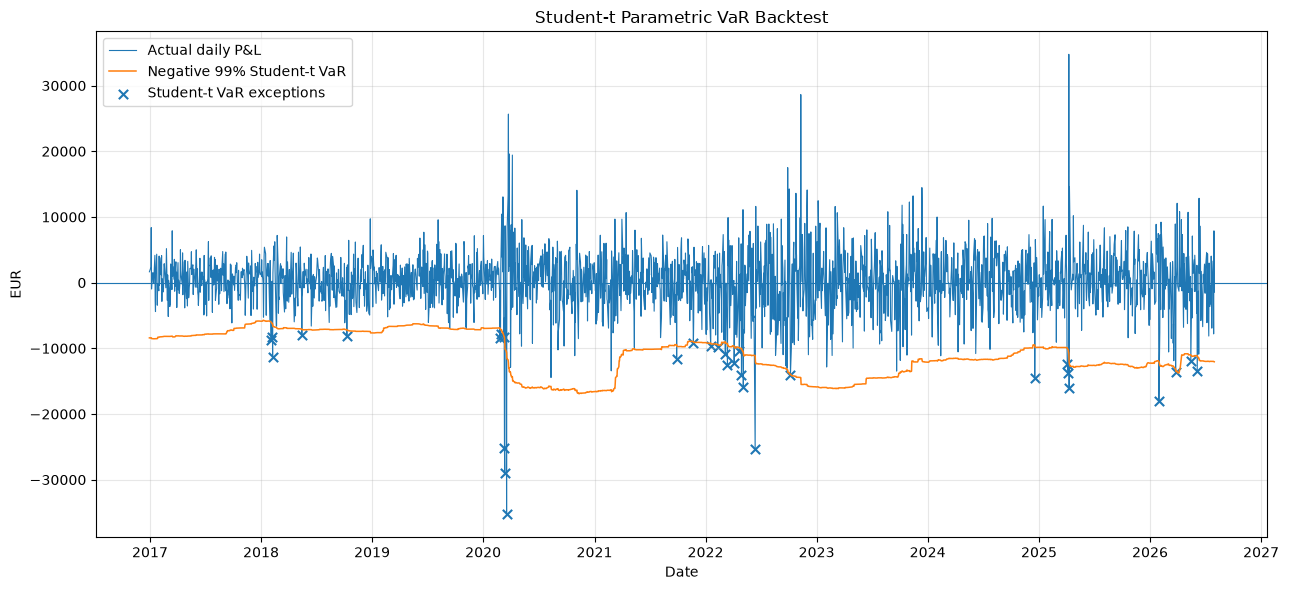

In [15]:
fig_student_t_backtest, ax = plt.subplots(
    figsize=(13, 6)
)

ax.plot(
    student_t_backtest_results.index,
    student_t_backtest_results[
        "actual_pnl_eur"
    ],
    linewidth=0.8,
    label="Actual daily P&L",
)

ax.plot(
    student_t_backtest_results.index,
    -student_t_backtest_results[
        "student_t_var_eur"
    ],
    linewidth=1.1,
    label="Negative 99% Student-t VaR",
)

student_t_exception_dates = (
    student_t_backtest_results[
        student_t_backtest_results[
            "student_t_exception"
        ]
    ]
)

ax.scatter(
    student_t_exception_dates.index,
    student_t_exception_dates[
        "actual_pnl_eur"
    ],
    marker="x",
    s=45,
    label="Student-t VaR exceptions",
)

ax.axhline(
    0,
    linewidth=0.8,
)

ax.set_title(
    "Student-t Parametric VaR Backtest"
)
ax.set_xlabel("Date")
ax.set_ylabel("EUR")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
distribution_diagnostics.to_csv(
    TABLES_DIR / "pnl_distribution_diagnostics.csv",
    index=False,
)

student_t_current_results.to_csv(
    TABLES_DIR / "student_t_current_var_es.csv",
    index=False,
)

student_t_backtest_results.to_csv(
    TABLES_DIR / "student_t_rolling_backtest.csv",
    index=True,
)

student_t_parameter_summary.to_csv(
    TABLES_DIR / "student_t_parameter_summary.csv",
    index=False,
)

student_t_exception_summary.to_csv(
    TABLES_DIR / "student_t_exception_summary.csv",
    index=False,
)

fig_pnl_normal.savefig(
    CHARTS_DIR / "recent_pnl_vs_normal_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

fig_student_t_backtest.savefig(
    CHARTS_DIR / "student_t_var_backtest.png",
    dpi=300,
    bbox_inches="tight",
)

print("Student-t model outputs saved.")

Student-t model outputs saved.


### Rolling Student-t interpretation

The rolling Student-t model produces 31 exceptions across 2,404 forecasts,
corresponding to an observed exception rate of approximately 1.29%.

This is substantially closer to the theoretical 1% exception rate than the
Normal Parametric, Monte Carlo Normal, EWMA Normal and ordinary Historical
Simulation models. It also improves on Weighted Historical Simulation, which
produced 35 exceptions.

The estimated degrees of freedom vary considerably through time. The median
estimate is approximately 9.81, indicating that heavy tails are relevant in
a typical estimation window. The minimum estimate of approximately 2.35
represents an extremely heavy-tailed period.

The maximum estimate is extremely large. This is not economically interpreted
as a literal degrees-of-freedom value. It indicates that, in some rolling
windows, the fitted Student-t distribution approaches its normal-distribution
limit.

Formal coverage and independence tests are required before concluding that
the model is adequately calibrated.

In [17]:
student_t_df_series = student_t_backtest_results[
    "student_t_degrees_of_freedom"
]

student_t_df_diagnostics = pd.DataFrame(
    {
        "diagnostic": [
            "Forecast windows",
            "Degrees of freedom below 5",
            "Degrees of freedom below 10",
            "Degrees of freedom above 100",
            "Degrees of freedom above 1,000",
            "Effectively normal share, df above 100",
        ],
        "value": [
            len(student_t_df_series),
            int((student_t_df_series < 5).sum()),
            int((student_t_df_series < 10).sum()),
            int((student_t_df_series > 100).sum()),
            int((student_t_df_series > 1_000).sum()),
            float((student_t_df_series > 100).mean()),
        ],
    }
)

display(
    student_t_df_diagnostics.style.format(
        {
            "value": lambda value: (
                f"{value:.2%}"
                if isinstance(value, float) and value < 1
                else f"{value:,.0f}"
            )
        }
    )
)

,diagnostic,value
0,Forecast windows,"2,404"
1,Degrees of freedom below 5,500
2,Degrees of freedom below 10,"1,224"
3,Degrees of freedom above 100,71
4,"Degrees of freedom above 1,000",36
5,"Effectively normal share, df above 100",2.95%


In [18]:
def kupiec_unconditional_coverage_test(
    exceptions: pd.Series,
    confidence_level: float,
) -> dict:
    """Perform the Kupiec unconditional-coverage test."""
    exception_values = (
        pd.Series(exceptions)
        .dropna()
        .astype(int)
    )

    observations = len(exception_values)

    if observations == 0:
        raise ValueError("The exception series is empty.")

    actual_exceptions = int(exception_values.sum())
    expected_probability = 1 - confidence_level
    observed_probability = actual_exceptions / observations

    null_log_likelihood = (
        xlogy(actual_exceptions, expected_probability)
        + xlogy(
            observations - actual_exceptions,
            1 - expected_probability,
        )
    )

    alternative_log_likelihood = (
        xlogy(actual_exceptions, observed_probability)
        + xlogy(
            observations - actual_exceptions,
            1 - observed_probability,
        )
    )

    lr_statistic = -2 * (
        null_log_likelihood
        - alternative_log_likelihood
    )

    p_value = chi2.sf(lr_statistic, df=1)

    return {
        "observations": observations,
        "expected_exceptions": (
            observations * expected_probability
        ),
        "actual_exceptions": actual_exceptions,
        "expected_probability": expected_probability,
        "observed_probability": observed_probability,
        "kupiec_lr_statistic": float(lr_statistic),
        "kupiec_p_value": float(p_value),
        "reject_unconditional_coverage_at_5_percent": (
            p_value < 0.05
        ),
    }

In [19]:
def christoffersen_independence_test(
    exceptions: pd.Series,
) -> dict:
    """Test whether VaR exceptions occur independently."""
    values = (
        pd.Series(exceptions)
        .dropna()
        .astype(int)
        .to_numpy()
    )

    if len(values) < 2:
        raise ValueError(
            "At least two observations are required."
        )

    previous = values[:-1]
    current = values[1:]

    n00 = int(
        ((previous == 0) & (current == 0)).sum()
    )
    n01 = int(
        ((previous == 0) & (current == 1)).sum()
    )
    n10 = int(
        ((previous == 1) & (current == 0)).sum()
    )
    n11 = int(
        ((previous == 1) & (current == 1)).sum()
    )

    total_transitions = n00 + n01 + n10 + n11
    total_exceptions = n01 + n11

    unconditional_probability = (
        total_exceptions / total_transitions
    )

    probability_after_no_exception = (
        n01 / (n00 + n01)
        if n00 + n01 > 0
        else 0.0
    )

    probability_after_exception = (
        n11 / (n10 + n11)
        if n10 + n11 > 0
        else 0.0
    )

    null_log_likelihood = (
        xlogy(
            n00 + n10,
            1 - unconditional_probability,
        )
        + xlogy(
            n01 + n11,
            unconditional_probability,
        )
    )

    alternative_log_likelihood = (
        xlogy(
            n00,
            1 - probability_after_no_exception,
        )
        + xlogy(
            n01,
            probability_after_no_exception,
        )
        + xlogy(
            n10,
            1 - probability_after_exception,
        )
        + xlogy(
            n11,
            probability_after_exception,
        )
    )

    lr_statistic = -2 * (
        null_log_likelihood
        - alternative_log_likelihood
    )

    p_value = chi2.sf(lr_statistic, df=1)

    return {
        "n00": n00,
        "n01": n01,
        "n10": n10,
        "n11": n11,
        "probability_after_no_exception": float(
            probability_after_no_exception
        ),
        "probability_after_exception": float(
            probability_after_exception
        ),
        "independence_lr_statistic": float(
            lr_statistic
        ),
        "independence_p_value": float(p_value),
        "reject_independence_at_5_percent": (
            p_value < 0.05
        ),
    }

In [20]:
student_t_kupiec = (
    kupiec_unconditional_coverage_test(
        exceptions=student_t_backtest_results[
            "student_t_exception"
        ],
        confidence_level=CONFIDENCE_LEVEL,
    )
)

student_t_independence = (
    christoffersen_independence_test(
        exceptions=student_t_backtest_results[
            "student_t_exception"
        ]
    )
)

student_t_conditional_coverage_lr = (
    student_t_kupiec["kupiec_lr_statistic"]
    + student_t_independence[
        "independence_lr_statistic"
    ]
)

student_t_conditional_coverage_p_value = chi2.sf(
    student_t_conditional_coverage_lr,
    df=2,
)

student_t_test_results = pd.DataFrame(
    {
        "model": ["Student-t Parametric"],
        "observations": [
            student_t_kupiec["observations"]
        ],
        "expected_exceptions": [
            student_t_kupiec["expected_exceptions"]
        ],
        "actual_exceptions": [
            student_t_kupiec["actual_exceptions"]
        ],
        "observed_exception_rate": [
            student_t_kupiec[
                "observed_probability"
            ]
        ],
        "kupiec_lr": [
            student_t_kupiec[
                "kupiec_lr_statistic"
            ]
        ],
        "kupiec_p_value": [
            student_t_kupiec[
                "kupiec_p_value"
            ]
        ],
        "reject_unconditional_coverage_at_5_percent": [
            student_t_kupiec[
                "reject_unconditional_coverage_at_5_percent"
            ]
        ],
        "probability_after_no_exception": [
            student_t_independence[
                "probability_after_no_exception"
            ]
        ],
        "probability_after_exception": [
            student_t_independence[
                "probability_after_exception"
            ]
        ],
        "independence_lr": [
            student_t_independence[
                "independence_lr_statistic"
            ]
        ],
        "independence_p_value": [
            student_t_independence[
                "independence_p_value"
            ]
        ],
        "reject_independence_at_5_percent": [
            student_t_independence[
                "reject_independence_at_5_percent"
            ]
        ],
        "conditional_coverage_lr": [
            student_t_conditional_coverage_lr
        ],
        "conditional_coverage_p_value": [
            student_t_conditional_coverage_p_value
        ],
        "reject_conditional_coverage_at_5_percent": [
            student_t_conditional_coverage_p_value
            < 0.05
        ],
    }
)

display(
    student_t_test_results.style.format(
        {
            "expected_exceptions": "{:.2f}",
            "observed_exception_rate": "{:.2%}",
            "kupiec_lr": "{:.4f}",
            "kupiec_p_value": "{:.6f}",
            "probability_after_no_exception": "{:.2%}",
            "probability_after_exception": "{:.2%}",
            "independence_lr": "{:.4f}",
            "independence_p_value": "{:.6f}",
            "conditional_coverage_lr": "{:.4f}",
            "conditional_coverage_p_value": "{:.6f}",
        }
    )
)

,model,observations,expected_exceptions,actual_exceptions,observed_exception_rate,kupiec_lr,kupiec_p_value,reject_unconditional_coverage_at_5_percent,probability_after_no_exception,probability_after_exception,independence_lr,independence_p_value,reject_independence_at_5_percent,conditional_coverage_lr,conditional_coverage_p_value,reject_conditional_coverage_at_5_percent
0,Student-t Parametric,2404,24.04,31,1.29%,1.8650,0.172049,False,1.18%,9.68%,7.3483,0.006713,True,9.2133,0.009985,True


In [21]:
student_t_df_diagnostics.to_csv(
    TABLES_DIR / "student_t_df_diagnostics.csv",
    index=False,
)

student_t_test_results.to_csv(
    TABLES_DIR / "student_t_backtesting_tests.csv",
    index=False,
)

print("Student-t diagnostic and backtesting results saved.")

Student-t diagnostic and backtesting results saved.


### Student-t backtesting interpretation

The rolling Student-t model produces 31 exceptions compared with approximately
24 expected exceptions. Its observed exception rate is 1.29%.

The Kupiec p-value is 0.1720, so correct unconditional coverage is not rejected
at the 5% significance level. This is the first model in the project to produce
an exception frequency statistically consistent with a 99% VaR model.

However, the probability of an exception following a non-exception is
approximately 1.18%, while the probability following another exception rises
to approximately 9.68%. The Christoffersen independence-test p-value is
0.0067, so exception independence is rejected.

The combined conditional-coverage p-value is approximately 0.0100. The model
therefore fails conditional coverage despite passing unconditional coverage.

The results suggest that heavier tails improve the overall calibration of VaR,
but a static 250-day volatility estimate does not react sufficiently to
volatility regime changes. The next model combines Student-t innovations with
EWMA volatility.

## 4. EWMA Student-t VaR

The static Student-t model captures heavy tails but uses one scale estimate
for the entire 250-day window.

The EWMA Student-t model separates time-varying volatility from the shape of
the shock distribution:

\[
P\&L_t = \sigma_t z_t,
\]

with the volatility recursion:

\[
\sigma_{t+1}^{2}
=
\lambda\sigma_t^{2}
+
(1-\lambda)(P\&L_t)^2.
\]

The standardized residuals are:

\[
z_t=\frac{P\&L_t}{\sigma_t}.
\]

A Student-t distribution is fitted to these standardized residuals. The
one-day-ahead EWMA volatility forecast is then combined with the fitted
Student-t quantile to calculate VaR and Expected Shortfall.

This specification aims to address both heavy tails and changing volatility
regimes.

In [22]:
def calculate_ewma_standardized_residuals(
    pnl_series: pd.Series,
    decay_factor: float = 0.94,
    initialization_window: int = 20,
) -> tuple[pd.Series, float]:
    """
    Calculate one-step-ahead EWMA volatilities and standardized residuals.

    The volatility used to standardize each observation is based only on
    information available before that observation.

    Returns
    -------
    tuple
        Standardized residual series and next-day volatility forecast.
    """
    if not 0 < decay_factor < 1:
        raise ValueError(
            "decay_factor must lie between zero and one."
        )

    clean_pnl = (
        pd.Series(pnl_series)
        .dropna()
        .astype(float)
    )

    if len(clean_pnl) <= initialization_window + 30:
        raise ValueError(
            "The P&L sample is too short for EWMA estimation."
        )

    if initialization_window < 2:
        raise ValueError(
            "initialization_window must be at least two."
        )

    pnl_values = clean_pnl.to_numpy(dtype=float)

    if not np.isfinite(pnl_values).all():
        raise ValueError(
            "pnl_series contains non-finite observations."
        )

    initial_variance = np.var(
        pnl_values[:initialization_window],
        ddof=1,
    )

    if not np.isfinite(initial_variance) or initial_variance <= 0:
        raise RuntimeError(
            "The initial EWMA variance is invalid."
        )

    current_variance = float(initial_variance)

    standardized_residuals = []
    residual_dates = []
    forecast_volatilities = []

    for observation_number in range(
        initialization_window,
        len(clean_pnl),
    ):
        forecast_volatility = np.sqrt(
            max(current_variance, 1e-12)
        )

        current_pnl = pnl_values[observation_number]

        standardized_residuals.append(
            current_pnl / forecast_volatility
        )

        residual_dates.append(
            clean_pnl.index[observation_number]
        )

        forecast_volatilities.append(
            forecast_volatility
        )

        # Update after observing the current P&L.
        current_variance = (
            decay_factor * current_variance
            + (1 - decay_factor) * current_pnl**2
        )

    residual_series = pd.Series(
        standardized_residuals,
        index=residual_dates,
        name="standardized_residual",
        dtype=float,
    )

    next_day_volatility = np.sqrt(
        max(current_variance, 1e-12)
    )

    residual_series.attrs[
        "forecast_volatilities"
    ] = np.asarray(forecast_volatilities)

    return residual_series, float(next_day_volatility)

In [23]:
def calculate_ewma_student_t_var_es(
    pnl_series: pd.Series,
    confidence_level: float,
    decay_factor: float = 0.94,
    initialization_window: int = 20,
) -> dict:
    """
    Calculate EWMA Student-t VaR and Expected Shortfall.
    """
    if not 0 < confidence_level < 1:
        raise ValueError(
            "confidence_level must lie between zero and one."
        )

    residuals, next_day_volatility = (
        calculate_ewma_standardized_residuals(
            pnl_series=pnl_series,
            decay_factor=decay_factor,
            initialization_window=initialization_window,
        )
    )

    fitted_df, fitted_location, fitted_scale = t.fit(
        residuals.to_numpy(dtype=float),
        floc=0.0,
    )

    if not np.isfinite(fitted_df) or fitted_df <= 1:
        raise RuntimeError(
            "The fitted Student-t degrees of freedom are invalid."
        )

    if not np.isfinite(fitted_scale) or fitted_scale <= 0:
        raise RuntimeError(
            "The fitted Student-t residual scale is invalid."
        )

    tail_probability = 1 - confidence_level

    standardized_quantile = t.ppf(
        tail_probability,
        df=fitted_df,
    )

    standardized_tail_density = t.pdf(
        standardized_quantile,
        df=fitted_df,
    )

    standardized_var = -(
        fitted_location
        + fitted_scale * standardized_quantile
    )

    standardized_es = (
        -fitted_location
        + fitted_scale
        * (
            fitted_df + standardized_quantile**2
        )
        / (
            fitted_df - 1
        )
        * standardized_tail_density
        / tail_probability
    )

    var_eur = (
        next_day_volatility
        * standardized_var
    )

    expected_shortfall_eur = (
        next_day_volatility
        * standardized_es
    )

    if var_eur <= 0:
        raise RuntimeError(
            "The calculated EWMA Student-t VaR is not positive."
        )

    if expected_shortfall_eur < var_eur - 1e-8:
        raise RuntimeError(
            "Expected Shortfall is below VaR."
        )

    return {
        "confidence_level": float(confidence_level),
        "decay_factor": float(decay_factor),
        "observations": int(len(pd.Series(pnl_series).dropna())),
        "residual_observations": int(len(residuals)),
        "degrees_of_freedom": float(fitted_df),
        "residual_location": float(fitted_location),
        "residual_scale": float(fitted_scale),
        "forecast_volatility_eur": float(
            next_day_volatility
        ),
        "standardized_var_multiplier": float(
            standardized_var
        ),
        "standardized_es_multiplier": float(
            standardized_es
        ),
        "var_eur": float(var_eur),
        "expected_shortfall_eur": float(
            expected_shortfall_eur
        ),
    }

In [24]:
ewma_t_current = calculate_ewma_student_t_var_es(
    pnl_series=recent_portfolio_pnl,
    confidence_level=CONFIDENCE_LEVEL,
    decay_factor=EWMA_LAMBDA,
    initialization_window=20,
)

ewma_t_current_results = pd.DataFrame(
    {
        "model": ["EWMA Student-t"],
        **{
            key: [value]
            for key, value in ewma_t_current.items()
        },
    }
)

display(
    ewma_t_current_results.style.format(
        {
            "confidence_level": "{:.0%}",
            "decay_factor": "{:.2f}",
            "degrees_of_freedom": "{:.3f}",
            "residual_location": "{:.4f}",
            "residual_scale": "{:.4f}",
            "forecast_volatility_eur": "EUR {:,.2f}",
            "standardized_var_multiplier": "{:.4f}",
            "standardized_es_multiplier": "{:.4f}",
            "var_eur": "EUR {:,.2f}",
            "expected_shortfall_eur": "EUR {:,.2f}",
        }
    )
)

,model,confidence_level,decay_factor,observations,residual_observations,degrees_of_freedom,residual_location,residual_scale,forecast_volatility_eur,standardized_var_multiplier,standardized_es_multiplier,var_eur,expected_shortfall_eur
0,EWMA Student-t,99%,0.94,250,230,7.015,0.0000,0.9116,"EUR 4,631.24",2.7314,3.4339,"EUR 12,649.88","EUR 15,903.36"


In [25]:
ewma_t_residuals, ewma_t_next_volatility = (
    calculate_ewma_standardized_residuals(
        pnl_series=recent_portfolio_pnl,
        decay_factor=EWMA_LAMBDA,
        initialization_window=20,
    )
)

ewma_t_residual_jb = jarque_bera(
    ewma_t_residuals
)

ewma_t_residual_diagnostics = pd.DataFrame(
    {
        "observations": [
            len(ewma_t_residuals)
        ],
        "mean": [
            ewma_t_residuals.mean()
        ],
        "volatility": [
            ewma_t_residuals.std(ddof=1)
        ],
        "skewness": [
            skew(
                ewma_t_residuals,
                bias=False,
            )
        ],
        "excess_kurtosis": [
            kurtosis(
                ewma_t_residuals,
                fisher=True,
                bias=False,
            )
        ],
        "jarque_bera_statistic": [
            ewma_t_residual_jb.statistic
        ],
        "jarque_bera_p_value": [
            ewma_t_residual_jb.pvalue
        ],
        "reject_normality_at_5_percent": [
            ewma_t_residual_jb.pvalue < 0.05
        ],
        "next_day_volatility_eur": [
            ewma_t_next_volatility
        ],
    }
)

display(
    ewma_t_residual_diagnostics.style.format(
        {
            "mean": "{:.4f}",
            "volatility": "{:.4f}",
            "skewness": "{:.4f}",
            "excess_kurtosis": "{:.4f}",
            "jarque_bera_statistic": "{:.4f}",
            "jarque_bera_p_value": "{:.8f}",
            "next_day_volatility_eur": "EUR {:,.2f}",
        }
    )
)

,observations,mean,volatility,skewness,excess_kurtosis,jarque_bera_statistic,jarque_bera_p_value,reject_normality_at_5_percent,next_day_volatility_eur
0,230,0.0862,1.0695,-0.3976,1.2253,19.1653,0.00006892,True,"EUR 4,631.24"


In [26]:
day_3_current_comparison = pd.DataFrame(
    {
        "model": [
            "Parametric Normal",
            "Student-t Parametric",
            "EWMA Student-t",
        ],
        "var_eur": [
            normal_var_eur,
            student_t_var_eur,
            ewma_t_current["var_eur"],
        ],
        "expected_shortfall_eur": [
            normal_es_eur,
            student_t_es_eur,
            ewma_t_current[
                "expected_shortfall_eur"
            ],
        ],
    }
)

day_3_current_comparison[
    "var_difference_vs_normal_eur"
] = (
    day_3_current_comparison["var_eur"]
    - normal_var_eur
)

day_3_current_comparison[
    "es_difference_vs_normal_eur"
] = (
    day_3_current_comparison[
        "expected_shortfall_eur"
    ]
    - normal_es_eur
)

display(
    day_3_current_comparison.style.format(
        {
            "var_eur": "EUR {:,.2f}",
            "expected_shortfall_eur": "EUR {:,.2f}",
            "var_difference_vs_normal_eur": "EUR {:+,.2f}",
            "es_difference_vs_normal_eur": "EUR {:+,.2f}",
        }
    )
)

,model,var_eur,expected_shortfall_eur,var_difference_vs_normal_eur,es_difference_vs_normal_eur
0,Parametric Normal,"EUR 10,698.74","EUR 12,257.16",EUR +0.00,EUR +0.00
1,Student-t Parametric,"EUR 12,069.50","EUR 15,660.26","EUR +1,370.76","EUR +3,403.10"
2,EWMA Student-t,"EUR 12,649.88","EUR 15,903.36","EUR +1,951.14","EUR +3,646.20"


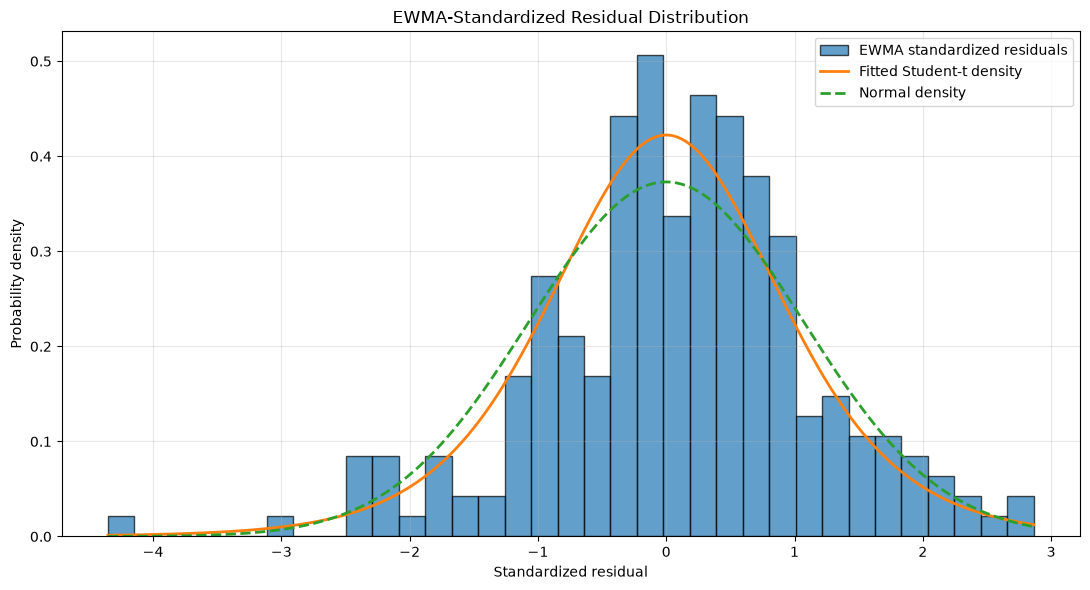

In [27]:
residual_grid = np.linspace(
    ewma_t_residuals.min(),
    ewma_t_residuals.max(),
    500,
)

fitted_residual_density = t.pdf(
    residual_grid,
    df=ewma_t_current["degrees_of_freedom"],
    loc=0.0,
    scale=ewma_t_current["residual_scale"],
)

normal_residual_density = norm.pdf(
    residual_grid,
    loc=0.0,
    scale=ewma_t_residuals.std(ddof=1),
)

fig_ewma_t_residuals, ax = plt.subplots(
    figsize=(11, 6)
)

ax.hist(
    ewma_t_residuals,
    bins=35,
    density=True,
    edgecolor="black",
    alpha=0.7,
    label="EWMA standardized residuals",
)

ax.plot(
    residual_grid,
    fitted_residual_density,
    linewidth=2,
    label="Fitted Student-t density",
)

ax.plot(
    residual_grid,
    normal_residual_density,
    linestyle="--",
    linewidth=2,
    label="Normal density",
)

ax.set_title(
    "EWMA-Standardized Residual Distribution"
)
ax.set_xlabel("Standardized residual")
ax.set_ylabel("Probability density")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### EWMA Student-t current-model interpretation

The current 99% EWMA Student-t VaR is approximately EUR 12,650, with an
Expected Shortfall of approximately EUR 15,903.

Relative to Parametric Normal, EWMA Student-t increases VaR by approximately
EUR 1,951, or 18.2%, and Expected Shortfall by approximately EUR 3,646, or
29.7%.

The fitted standardized-residual distribution has approximately 7.02 degrees
of freedom, indicating heavier tails than a normal distribution. The current
EWMA volatility forecast is approximately EUR 4,631.

The standardized residuals retain negative skewness and positive excess
kurtosis. Their Jarque–Bera p-value is below 0.001, so residual normality is
rejected. Volatility filtering therefore reduces but does not remove
non-normality.

The EWMA Student-t model is currently more conservative than the static
Student-t model because its higher forecast volatility more than offsets its
slightly lighter fitted tail.

### 4.1 Rolling EWMA Student-t backtest

For each forecast date, the preceding 250 portfolio P&L observations are used.

Within each estimation window:

1. The first 20 observations initialize the EWMA variance.
2. One-step-ahead EWMA volatilities are calculated without look-ahead bias.
3. The remaining 230 P&L observations are standardized by their corresponding
   volatility forecasts.
4. A zero-location Student-t distribution is fitted to the standardized
   residuals.
5. The fitted tail quantile is multiplied by the next-day EWMA volatility
   forecast.

The realised P&L on the forecast date is excluded from all estimation steps.

In [28]:
rolling_ewma_t_records = []

number_of_forecasts = (
    len(portfolio_pnl) - LOOKBACK_WINDOW
)

for observation_number in range(
    LOOKBACK_WINDOW,
    len(portfolio_pnl),
):
    forecast_number = (
        observation_number
        - LOOKBACK_WINDOW
        + 1
    )

    forecast_date = portfolio_pnl.index[
        observation_number
    ]

    estimation_sample = portfolio_pnl.iloc[
        observation_number - LOOKBACK_WINDOW:
        observation_number
    ]

    try:
        forecast_result = (
            calculate_ewma_student_t_var_es(
                pnl_series=estimation_sample,
                confidence_level=CONFIDENCE_LEVEL,
                decay_factor=EWMA_LAMBDA,
                initialization_window=20,
            )
        )
    except Exception as error:
        raise RuntimeError(
            f"EWMA Student-t estimation failed for "
            f"{forecast_date.date()}."
        ) from error

    actual_pnl = float(
        portfolio_pnl.iloc[observation_number]
    )

    forecast_var = float(
        forecast_result["var_eur"]
    )

    exception = actual_pnl < -forecast_var

    rolling_ewma_t_records.append(
        {
            "date": forecast_date,
            "actual_pnl_eur": actual_pnl,
            "ewma_t_forecast_volatility_eur": (
                forecast_result[
                    "forecast_volatility_eur"
                ]
            ),
            "ewma_t_degrees_of_freedom": (
                forecast_result[
                    "degrees_of_freedom"
                ]
            ),
            "ewma_t_residual_scale": (
                forecast_result[
                    "residual_scale"
                ]
            ),
            "ewma_t_var_multiplier": (
                forecast_result[
                    "standardized_var_multiplier"
                ]
            ),
            "ewma_t_var_eur": forecast_var,
            "ewma_t_es_eur": (
                forecast_result[
                    "expected_shortfall_eur"
                ]
            ),
            "ewma_t_exception": exception,
        }
    )

    if (
        forecast_number % 500 == 0
        or forecast_number == number_of_forecasts
    ):
        print(
            f"Completed {forecast_number:,} of "
            f"{number_of_forecasts:,} forecasts."
        )

ewma_t_backtest_results = (
    pd.DataFrame(rolling_ewma_t_records)
    .set_index("date")
)

print(
    f"EWMA Student-t forecasts completed: "
    f"{len(ewma_t_backtest_results):,}"
)

display(ewma_t_backtest_results.head())

Completed 500 of 2,404 forecasts.
Completed 1,000 of 2,404 forecasts.
Completed 1,500 of 2,404 forecasts.
Completed 2,000 of 2,404 forecasts.
Completed 2,404 of 2,404 forecasts.
EWMA Student-t forecasts completed: 2,404


,actual_pnl_eur,ewma_t_forecast_volatility_eur,ewma_t_degrees_of_freedom,ewma_t_residual_scale,ewma_t_var_multiplier,ewma_t_var_eur,ewma_t_es_eur,ewma_t_exception
date,,,,,,,,
2016-12-30,1654.611656,3522.763655,6.482354,0.877565,2.690530,9478.101515,12032.451290,False
2017-01-03,2194.106621,3439.409344,6.517655,0.877167,2.684870,9234.368370,11714.750442,False
2017-01-04,2403.266442,3377.663461,6.438488,0.868721,2.668965,9014.866174,11454.580862,False
2017-01-05,8378.931018,3327.256409,6.570621,0.872969,2.665502,8868.807671,11239.271794,False
2017-01-06,-965.687886,3823.452140,6.306533,0.874849,2.705188,10343.158603,13178.861321,False


In [29]:
assert (
    len(ewma_t_backtest_results)
    == len(portfolio_pnl) - LOOKBACK_WINDOW
)

assert (
    ewma_t_backtest_results
    .index
    .is_monotonic_increasing
)

assert not (
    ewma_t_backtest_results
    .isna()
    .any()
    .any()
)

assert (
    ewma_t_backtest_results[
        "ewma_t_forecast_volatility_eur"
    ] > 0
).all()

assert (
    ewma_t_backtest_results[
        "ewma_t_degrees_of_freedom"
    ] > 1
).all()

assert (
    ewma_t_backtest_results[
        "ewma_t_var_eur"
    ] > 0
).all()

assert np.all(
    ewma_t_backtest_results[
        "ewma_t_es_eur"
    ]
    >= ewma_t_backtest_results[
        "ewma_t_var_eur"
    ] - 1e-8
)

print("Rolling EWMA Student-t results validated successfully.")

Rolling EWMA Student-t results validated successfully.


In [30]:
ewma_t_parameter_summary = pd.DataFrame(
    {
        "statistic": [
            "Minimum",
            "25th percentile",
            "Median",
            "75th percentile",
            "Maximum",
        ],
        "degrees_of_freedom": [
            ewma_t_backtest_results[
                "ewma_t_degrees_of_freedom"
            ].min(),
            ewma_t_backtest_results[
                "ewma_t_degrees_of_freedom"
            ].quantile(0.25),
            ewma_t_backtest_results[
                "ewma_t_degrees_of_freedom"
            ].median(),
            ewma_t_backtest_results[
                "ewma_t_degrees_of_freedom"
            ].quantile(0.75),
            ewma_t_backtest_results[
                "ewma_t_degrees_of_freedom"
            ].max(),
        ],
        "forecast_volatility_eur": [
            ewma_t_backtest_results[
                "ewma_t_forecast_volatility_eur"
            ].min(),
            ewma_t_backtest_results[
                "ewma_t_forecast_volatility_eur"
            ].quantile(0.25),
            ewma_t_backtest_results[
                "ewma_t_forecast_volatility_eur"
            ].median(),
            ewma_t_backtest_results[
                "ewma_t_forecast_volatility_eur"
            ].quantile(0.75),
            ewma_t_backtest_results[
                "ewma_t_forecast_volatility_eur"
            ].max(),
        ],
        "var_eur": [
            ewma_t_backtest_results[
                "ewma_t_var_eur"
            ].min(),
            ewma_t_backtest_results[
                "ewma_t_var_eur"
            ].quantile(0.25),
            ewma_t_backtest_results[
                "ewma_t_var_eur"
            ].median(),
            ewma_t_backtest_results[
                "ewma_t_var_eur"
            ].quantile(0.75),
            ewma_t_backtest_results[
                "ewma_t_var_eur"
            ].max(),
        ],
    }
)

display(
    ewma_t_parameter_summary.style.format(
        {
            "degrees_of_freedom": "{:,.3f}",
            "forecast_volatility_eur": "EUR {:,.2f}",
            "var_eur": "EUR {:,.2f}",
        }
    )
)

,statistic,degrees_of_freedom,forecast_volatility_eur,var_eur
0,Minimum,3.152,"EUR 1,836.48","EUR 4,139.14"
1,25th percentile,6.218,"EUR 3,075.59","EUR 7,740.22"
2,Median,10.627,"EUR 3,812.02","EUR 10,085.04"
3,75th percentile,22.730,"EUR 4,906.21","EUR 13,002.07"
4,Maximum,"40,854,991,864,555.109","EUR 13,808.57","EUR 42,692.02"


In [31]:
ewma_t_observations = len(
    ewma_t_backtest_results
)

ewma_t_actual_exceptions = int(
    ewma_t_backtest_results[
        "ewma_t_exception"
    ].sum()
)

ewma_t_exception_summary = pd.DataFrame(
    {
        "model": ["EWMA Student-t"],
        "observations": [
            ewma_t_observations
        ],
        "expected_exceptions": [
            ewma_t_observations
            * TAIL_PROBABILITY
        ],
        "actual_exceptions": [
            ewma_t_actual_exceptions
        ],
        "expected_exception_rate": [
            TAIL_PROBABILITY
        ],
        "actual_exception_rate": [
            ewma_t_actual_exceptions
            / ewma_t_observations
        ],
    }
)

ewma_t_exception_summary[
    "exception_difference"
] = (
    ewma_t_exception_summary[
        "actual_exceptions"
    ]
    - ewma_t_exception_summary[
        "expected_exceptions"
    ]
)

display(
    ewma_t_exception_summary.style.format(
        {
            "expected_exceptions": "{:.2f}",
            "expected_exception_rate": "{:.2%}",
            "actual_exception_rate": "{:.2%}",
            "exception_difference": "{:+.2f}",
        }
    )
)

,model,observations,expected_exceptions,actual_exceptions,expected_exception_rate,actual_exception_rate,exception_difference
0,EWMA Student-t,2404,24.04,32,1.00%,1.33%,+7.96


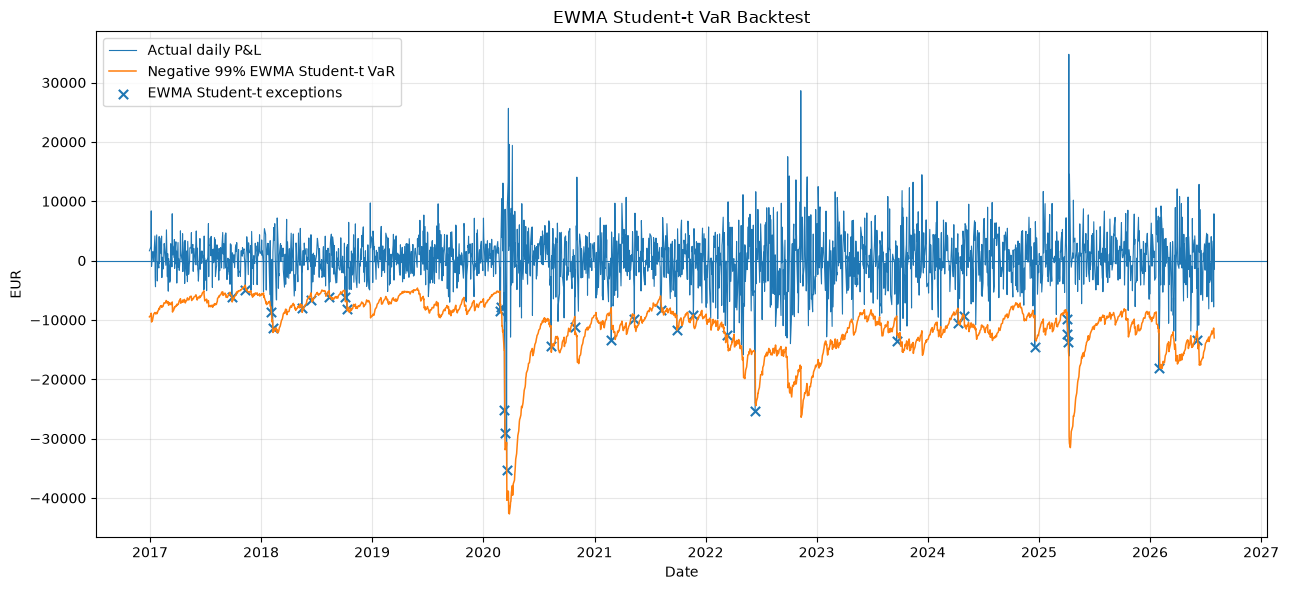

In [32]:
fig_ewma_t_backtest, ax = plt.subplots(
    figsize=(13, 6)
)

ax.plot(
    ewma_t_backtest_results.index,
    ewma_t_backtest_results[
        "actual_pnl_eur"
    ],
    linewidth=0.8,
    label="Actual daily P&L",
)

ax.plot(
    ewma_t_backtest_results.index,
    -ewma_t_backtest_results[
        "ewma_t_var_eur"
    ],
    linewidth=1.1,
    label="Negative 99% EWMA Student-t VaR",
)

ewma_t_exception_dates = (
    ewma_t_backtest_results[
        ewma_t_backtest_results[
            "ewma_t_exception"
        ]
    ]
)

ax.scatter(
    ewma_t_exception_dates.index,
    ewma_t_exception_dates[
        "actual_pnl_eur"
    ],
    marker="x",
    s=45,
    label="EWMA Student-t exceptions",
)

ax.axhline(
    0,
    linewidth=0.8,
)

ax.set_title(
    "EWMA Student-t VaR Backtest"
)
ax.set_xlabel("Date")
ax.set_ylabel("EUR")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
ewma_t_current_results.to_csv(
    TABLES_DIR / "ewma_student_t_current_var_es.csv",
    index=False,
)

ewma_t_residual_diagnostics.to_csv(
    TABLES_DIR / "ewma_student_t_residual_diagnostics.csv",
    index=False,
)

ewma_t_backtest_results.to_csv(
    TABLES_DIR / "ewma_student_t_rolling_backtest.csv",
    index=True,
)

ewma_t_parameter_summary.to_csv(
    TABLES_DIR / "ewma_student_t_parameter_summary.csv",
    index=False,
)

ewma_t_exception_summary.to_csv(
    TABLES_DIR / "ewma_student_t_exception_summary.csv",
    index=False,
)

fig_ewma_t_residuals.savefig(
    CHARTS_DIR / "ewma_student_t_residual_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

fig_ewma_t_backtest.savefig(
    CHARTS_DIR / "ewma_student_t_var_backtest.png",
    dpi=300,
    bbox_inches="tight",
)

print("EWMA Student-t outputs saved.")

EWMA Student-t outputs saved.


### Rolling EWMA Student-t interpretation

The rolling EWMA Student-t model produces 32 exceptions across 2,404
forecasts, corresponding to an observed exception rate of approximately
1.33%.

This is substantially closer to the theoretical 1% rate than the Normal,
Monte Carlo and Historical Simulation specifications. However, it produces
one more exception than the static Student-t model.

The model's forecast volatility changes substantially through time. Its median
one-day volatility forecast is approximately EUR 3,812, while its maximum is
approximately EUR 13,809. Correspondingly, the rolling VaR estimates range
from approximately EUR 4,139 to EUR 42,692.

The large variation shows that EWMA responds strongly to changing market
conditions. The remaining question is whether this responsiveness reduces the
clustering of VaR exceptions.

Extremely large fitted degrees-of-freedom estimates indicate estimation
windows in which the Student-t distribution approaches its normal-distribution
limit rather than economically meaningful literal parameter values.

In [34]:
ewma_t_kupiec = kupiec_unconditional_coverage_test(
    exceptions=ewma_t_backtest_results[
        "ewma_t_exception"
    ],
    confidence_level=CONFIDENCE_LEVEL,
)

ewma_t_independence = christoffersen_independence_test(
    exceptions=ewma_t_backtest_results[
        "ewma_t_exception"
    ]
)

ewma_t_conditional_coverage_lr = (
    ewma_t_kupiec["kupiec_lr_statistic"]
    + ewma_t_independence[
        "independence_lr_statistic"
    ]
)

ewma_t_conditional_coverage_p_value = chi2.sf(
    ewma_t_conditional_coverage_lr,
    df=2,
)

ewma_t_test_results = pd.DataFrame(
    {
        "model": ["EWMA Student-t"],
        "observations": [
            ewma_t_kupiec["observations"]
        ],
        "expected_exceptions": [
            ewma_t_kupiec["expected_exceptions"]
        ],
        "actual_exceptions": [
            ewma_t_kupiec["actual_exceptions"]
        ],
        "observed_exception_rate": [
            ewma_t_kupiec[
                "observed_probability"
            ]
        ],
        "kupiec_lr": [
            ewma_t_kupiec[
                "kupiec_lr_statistic"
            ]
        ],
        "kupiec_p_value": [
            ewma_t_kupiec[
                "kupiec_p_value"
            ]
        ],
        "reject_unconditional_coverage_at_5_percent": [
            ewma_t_kupiec[
                "reject_unconditional_coverage_at_5_percent"
            ]
        ],
        "probability_after_no_exception": [
            ewma_t_independence[
                "probability_after_no_exception"
            ]
        ],
        "probability_after_exception": [
            ewma_t_independence[
                "probability_after_exception"
            ]
        ],
        "independence_lr": [
            ewma_t_independence[
                "independence_lr_statistic"
            ]
        ],
        "independence_p_value": [
            ewma_t_independence[
                "independence_p_value"
            ]
        ],
        "reject_independence_at_5_percent": [
            ewma_t_independence[
                "reject_independence_at_5_percent"
            ]
        ],
        "conditional_coverage_lr": [
            ewma_t_conditional_coverage_lr
        ],
        "conditional_coverage_p_value": [
            ewma_t_conditional_coverage_p_value
        ],
        "reject_conditional_coverage_at_5_percent": [
            ewma_t_conditional_coverage_p_value
            < 0.05
        ],
    }
)

display(
    ewma_t_test_results.style.format(
        {
            "expected_exceptions": "{:.2f}",
            "observed_exception_rate": "{:.2%}",
            "kupiec_lr": "{:.4f}",
            "kupiec_p_value": "{:.6f}",
            "probability_after_no_exception": "{:.2%}",
            "probability_after_exception": "{:.2%}",
            "independence_lr": "{:.4f}",
            "independence_p_value": "{:.6f}",
            "conditional_coverage_lr": "{:.4f}",
            "conditional_coverage_p_value": "{:.6f}",
        }
    )
)

,model,observations,expected_exceptions,actual_exceptions,observed_exception_rate,kupiec_lr,kupiec_p_value,reject_unconditional_coverage_at_5_percent,probability_after_no_exception,probability_after_exception,independence_lr,independence_p_value,reject_independence_at_5_percent,conditional_coverage_lr,conditional_coverage_p_value,reject_conditional_coverage_at_5_percent
0,EWMA Student-t,2404,24.04,32,1.33%,2.4117,0.120429,False,1.22%,9.38%,6.9963,0.008168,True,9.4080,0.009059,True


In [35]:
ewma_t_df_series = ewma_t_backtest_results[
    "ewma_t_degrees_of_freedom"
]

ewma_t_df_diagnostics = pd.DataFrame(
    {
        "diagnostic": [
            "Forecast windows",
            "Degrees of freedom below 5",
            "Degrees of freedom below 10",
            "Degrees of freedom above 100",
            "Degrees of freedom above 1,000",
            "Effectively normal share, df above 100",
        ],
        "value": [
            len(ewma_t_df_series),
            int((ewma_t_df_series < 5).sum()),
            int((ewma_t_df_series < 10).sum()),
            int((ewma_t_df_series > 100).sum()),
            int((ewma_t_df_series > 1_000).sum()),
            float((ewma_t_df_series > 100).mean()),
        ],
    }
)

display(ewma_t_df_diagnostics)

,diagnostic,value
0,Forecast windows,2404.000000
1,Degrees of freedom below 5,381.000000
2,Degrees of freedom below 10,1139.000000
3,Degrees of freedom above 100,304.000000
4,"Degrees of freedom above 1,000",242.000000
5,"Effectively normal share, df above 100",0.126456


In [36]:
ewma_t_test_results.to_csv(
    TABLES_DIR / "ewma_student_t_backtesting_tests.csv",
    index=False,
)

ewma_t_df_diagnostics.to_csv(
    TABLES_DIR / "ewma_student_t_df_diagnostics.csv",
    index=False,
)

print("EWMA Student-t backtesting results saved.")

EWMA Student-t backtesting results saved.


### EWMA Student-t backtesting interpretation

The EWMA Student-t model produces 32 exceptions across 2,404 forecasts,
corresponding to an observed exception rate of approximately 1.33%.

The Kupiec p-value is 0.1204, so correct unconditional coverage is not rejected
at the 5% significance level. The model therefore produces an acceptable
overall exception frequency.

However, the probability of an exception following a non-exception is
approximately 1.22%, while the probability following another exception rises
to approximately 9.38%. The Christoffersen independence-test p-value is
0.0082, so exception independence is rejected.

The combined conditional-coverage p-value is approximately 0.0091. EWMA
Student-t therefore fails conditional coverage because its exceptions remain
clustered.

Adding EWMA volatility does not materially improve on the static Student-t
model in the current specification. EWMA reacts after a large observation has
occurred, but it cannot fully anticipate the first loss associated with a new
stress regime.

## 5. Filtered Historical Simulation

Filtered Historical Simulation combines time-varying volatility with the
empirical distribution of standardized historical shocks.

Portfolio P&L is decomposed as:

\[
P\&L_t = \sigma_t z_t,
\]

where \(\sigma_t\) is estimated using EWMA and \(z_t\) is the corresponding
standardized residual.

The historical residuals are then applied to the next-day volatility forecast:

\[
P\&L_{t+1}^{(s)}
=
\widehat{\sigma}_{t+1}z_s.
\]

Unlike EWMA Student-t, Filtered Historical Simulation does not impose a
symmetric parametric distribution. It retains the observed skewness, tail
shape and unusual shocks contained in the standardized-residual sample.

With a 250-day estimation window and a 20-day initialization period, the model
uses 230 residual scenarios. At a 99% confidence level, the Expected Shortfall
estimate is therefore based on only 2.3 effective tail scenarios. The estimate
should consequently be interpreted as statistically noisy, motivating later
lookback-window sensitivity analysis.

In [37]:
def calculate_equal_weight_var_es(
    scenarios: np.ndarray,
    confidence_level: float,
) -> dict:
    """
    Calculate empirical VaR and Expected Shortfall from equally weighted
    scenarios.

    Expected Shortfall uses exactly the requested lower-tail probability,
    including a fractional boundary scenario when necessary.
    """
    if not 0 < confidence_level < 1:
        raise ValueError(
            "confidence_level must lie between zero and one."
        )

    scenario_values = np.asarray(
        scenarios,
        dtype=float,
    ).reshape(-1)

    if len(scenario_values) == 0:
        raise ValueError(
            "The scenario array cannot be empty."
        )

    if not np.isfinite(scenario_values).all():
        raise ValueError(
            "The scenario array contains non-finite values."
        )

    sorted_scenarios = np.sort(
        scenario_values
    )

    observations = len(sorted_scenarios)
    scenario_weight = 1.0 / observations
    tail_probability = 1 - confidence_level

    cumulative_weights = (
        np.arange(1, observations + 1)
        * scenario_weight
    )

    boundary_position = int(
        np.searchsorted(
            cumulative_weights,
            tail_probability,
            side="left",
        )
    )

    if boundary_position >= observations:
        raise RuntimeError(
            "Unable to identify the empirical VaR boundary."
        )

    pnl_quantile = float(
        sorted_scenarios[boundary_position]
    )

    var_eur = -pnl_quantile

    cumulative_weight_before = (
        np.arange(observations)
        * scenario_weight
    )

    allocated_tail_weights = np.clip(
        tail_probability
        - cumulative_weight_before,
        0.0,
        scenario_weight,
    )

    allocated_tail_probability = float(
        allocated_tail_weights.sum()
    )

    if not np.isclose(
        allocated_tail_probability,
        tail_probability,
        atol=1e-12,
    ):
        raise RuntimeError(
            "The allocated tail probability is incorrect."
        )

    expected_shortfall_eur = -float(
        np.sum(
            sorted_scenarios
            * allocated_tail_weights
        )
        / allocated_tail_probability
    )

    if expected_shortfall_eur < var_eur - 1e-8:
        raise RuntimeError(
            "Expected Shortfall is materially below VaR."
        )

    return {
        "scenario_observations": observations,
        "tail_probability": tail_probability,
        "effective_tail_scenarios": (
            tail_probability * observations
        ),
        "tail_scenarios_with_positive_weight": int(
            (allocated_tail_weights > 0).sum()
        ),
        "var_eur": float(var_eur),
        "expected_shortfall_eur": float(
            expected_shortfall_eur
        ),
    }

In [38]:
def calculate_filtered_historical_var_es(
    pnl_series: pd.Series,
    confidence_level: float,
    decay_factor: float = 0.94,
    initialization_window: int = 20,
) -> tuple[dict, pd.Series]:
    """
    Calculate Filtered Historical Simulation VaR and Expected Shortfall.

    Returns
    -------
    tuple
        Result dictionary and filtered one-day P&L scenario series.
    """
    residuals, next_day_volatility = (
        calculate_ewma_standardized_residuals(
            pnl_series=pnl_series,
            decay_factor=decay_factor,
            initialization_window=initialization_window,
        )
    )

    filtered_scenarios = (
        residuals
        * next_day_volatility
    )

    filtered_scenarios.name = (
        "filtered_pnl_scenario_eur"
    )

    empirical_result = (
        calculate_equal_weight_var_es(
            scenarios=filtered_scenarios.to_numpy(),
            confidence_level=confidence_level,
        )
    )

    result = {
        "confidence_level": float(
            confidence_level
        ),
        "decay_factor": float(
            decay_factor
        ),
        "observations": int(
            len(pd.Series(pnl_series).dropna())
        ),
        "residual_observations": int(
            len(residuals)
        ),
        "forecast_volatility_eur": float(
            next_day_volatility
        ),
        "residual_mean": float(
            residuals.mean()
        ),
        "residual_volatility": float(
            residuals.std(ddof=1)
        ),
        "residual_skewness": float(
            skew(
                residuals,
                bias=False,
            )
        ),
        "residual_excess_kurtosis": float(
            kurtosis(
                residuals,
                fisher=True,
                bias=False,
            )
        ),
        **empirical_result,
    }

    return result, filtered_scenarios

In [39]:
fhs_current, fhs_current_scenarios = (
    calculate_filtered_historical_var_es(
        pnl_series=recent_portfolio_pnl,
        confidence_level=CONFIDENCE_LEVEL,
        decay_factor=EWMA_LAMBDA,
        initialization_window=20,
    )
)

fhs_current_results = pd.DataFrame(
    {
        "model": [
            "Filtered Historical Simulation"
        ],
        **{
            key: [value]
            for key, value in fhs_current.items()
        },
    }
)

assert fhs_current["var_eur"] > 0

assert (
    fhs_current["expected_shortfall_eur"]
    >= fhs_current["var_eur"] - 1e-8
)

display(
    fhs_current_results.style.format(
        {
            "confidence_level": "{:.0%}",
            "decay_factor": "{:.2f}",
            "forecast_volatility_eur": "EUR {:,.2f}",
            "residual_mean": "{:.4f}",
            "residual_volatility": "{:.4f}",
            "residual_skewness": "{:.4f}",
            "residual_excess_kurtosis": "{:.4f}",
            "tail_probability": "{:.2%}",
            "effective_tail_scenarios": "{:.2f}",
            "var_eur": "EUR {:,.2f}",
            "expected_shortfall_eur": "EUR {:,.2f}",
        }
    )
)

,model,confidence_level,decay_factor,observations,residual_observations,forecast_volatility_eur,residual_mean,residual_volatility,residual_skewness,residual_excess_kurtosis,scenario_observations,tail_probability,effective_tail_scenarios,tail_scenarios_with_positive_weight,var_eur,expected_shortfall_eur
0,Filtered Historical Simulation,99%,0.94,250,230,"EUR 4,631.24",0.0862,1.0695,-0.3976,1.2253,230,1.00%,2.30,3,"EUR 11,504.04","EUR 16,371.68"


In [40]:
day_3_current_comparison = pd.DataFrame(
    {
        "model": [
            "Parametric Normal",
            "Student-t Parametric",
            "EWMA Student-t",
            "Filtered Historical Simulation",
        ],
        "var_eur": [
            normal_var_eur,
            student_t_var_eur,
            ewma_t_current["var_eur"],
            fhs_current["var_eur"],
        ],
        "expected_shortfall_eur": [
            normal_es_eur,
            student_t_es_eur,
            ewma_t_current[
                "expected_shortfall_eur"
            ],
            fhs_current[
                "expected_shortfall_eur"
            ],
        ],
    }
)

day_3_current_comparison[
    "var_difference_vs_normal_eur"
] = (
    day_3_current_comparison["var_eur"]
    - normal_var_eur
)

day_3_current_comparison[
    "es_difference_vs_normal_eur"
] = (
    day_3_current_comparison[
        "expected_shortfall_eur"
    ]
    - normal_es_eur
)

display(
    day_3_current_comparison.style.format(
        {
            "var_eur": "EUR {:,.2f}",
            "expected_shortfall_eur": "EUR {:,.2f}",
            "var_difference_vs_normal_eur": "EUR {:+,.2f}",
            "es_difference_vs_normal_eur": "EUR {:+,.2f}",
        }
    )
)

,model,var_eur,expected_shortfall_eur,var_difference_vs_normal_eur,es_difference_vs_normal_eur
0,Parametric Normal,"EUR 10,698.74","EUR 12,257.16",EUR +0.00,EUR +0.00
1,Student-t Parametric,"EUR 12,069.50","EUR 15,660.26","EUR +1,370.76","EUR +3,403.10"
2,EWMA Student-t,"EUR 12,649.88","EUR 15,903.36","EUR +1,951.14","EUR +3,646.20"
3,Filtered Historical Simulation,"EUR 11,504.04","EUR 16,371.68",EUR +805.30,"EUR +4,114.51"


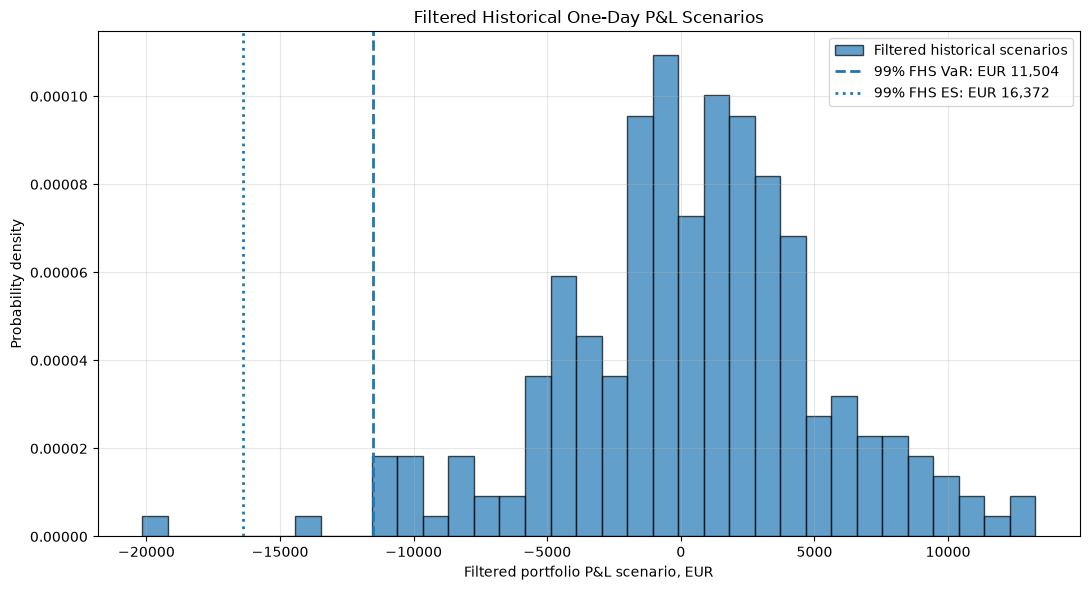

In [41]:
fig_fhs_distribution, ax = plt.subplots(
    figsize=(11, 6)
)

ax.hist(
    fhs_current_scenarios,
    bins=35,
    density=True,
    edgecolor="black",
    alpha=0.7,
    label="Filtered historical scenarios",
)

ax.axvline(
    -fhs_current["var_eur"],
    linestyle="--",
    linewidth=2,
    label=(
        f"99% FHS VaR: "
        f"EUR {fhs_current['var_eur']:,.0f}"
    ),
)

ax.axvline(
    -fhs_current["expected_shortfall_eur"],
    linestyle=":",
    linewidth=2,
    label=(
        f"99% FHS ES: "
        f"EUR "
        f"{fhs_current['expected_shortfall_eur']:,.0f}"
    ),
)

ax.set_title(
    "Filtered Historical One-Day P&L Scenarios"
)
ax.set_xlabel("Filtered portfolio P&L scenario, EUR")
ax.set_ylabel("Probability density")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.1 Rolling Filtered Historical Simulation backtest

For every forecast date, the preceding 250 portfolio P&L observations are
filtered using EWMA.

The resulting 230 standardized residuals are scaled by the one-day-ahead
volatility forecast. VaR and Expected Shortfall are then calculated from the
empirical filtered-scenario distribution.

The forecast-date P&L is excluded from the estimation sample, preventing
look-ahead bias.

In [42]:
rolling_fhs_records = []

number_of_forecasts = (
    len(portfolio_pnl) - LOOKBACK_WINDOW
)

for observation_number in range(
    LOOKBACK_WINDOW,
    len(portfolio_pnl),
):
    forecast_number = (
        observation_number
        - LOOKBACK_WINDOW
        + 1
    )

    forecast_date = portfolio_pnl.index[
        observation_number
    ]

    estimation_sample = portfolio_pnl.iloc[
        observation_number - LOOKBACK_WINDOW:
        observation_number
    ]

    try:
        forecast_result, _ = (
            calculate_filtered_historical_var_es(
                pnl_series=estimation_sample,
                confidence_level=CONFIDENCE_LEVEL,
                decay_factor=EWMA_LAMBDA,
                initialization_window=20,
            )
        )
    except Exception as error:
        raise RuntimeError(
            f"Filtered Historical Simulation failed "
            f"for {forecast_date.date()}."
        ) from error

    actual_pnl = float(
        portfolio_pnl.iloc[observation_number]
    )

    forecast_var = float(
        forecast_result["var_eur"]
    )

    exception = actual_pnl < -forecast_var

    rolling_fhs_records.append(
        {
            "date": forecast_date,
            "actual_pnl_eur": actual_pnl,
            "fhs_forecast_volatility_eur": (
                forecast_result[
                    "forecast_volatility_eur"
                ]
            ),
            "fhs_residual_skewness": (
                forecast_result[
                    "residual_skewness"
                ]
            ),
            "fhs_residual_excess_kurtosis": (
                forecast_result[
                    "residual_excess_kurtosis"
                ]
            ),
            "fhs_var_eur": forecast_var,
            "fhs_es_eur": (
                forecast_result[
                    "expected_shortfall_eur"
                ]
            ),
            "fhs_exception": exception,
        }
    )

    if (
        forecast_number % 500 == 0
        or forecast_number == number_of_forecasts
    ):
        print(
            f"Completed {forecast_number:,} of "
            f"{number_of_forecasts:,} forecasts."
        )

fhs_backtest_results = (
    pd.DataFrame(rolling_fhs_records)
    .set_index("date")
)

print(
    f"Filtered Historical forecasts completed: "
    f"{len(fhs_backtest_results):,}"
)

display(fhs_backtest_results.head())

Completed 500 of 2,404 forecasts.
Completed 1,000 of 2,404 forecasts.
Completed 1,500 of 2,404 forecasts.
Completed 2,000 of 2,404 forecasts.
Completed 2,404 of 2,404 forecasts.
Filtered Historical forecasts completed: 2,404


,actual_pnl_eur,fhs_forecast_volatility_eur,fhs_residual_skewness,fhs_residual_excess_kurtosis,fhs_var_eur,fhs_es_eur,fhs_exception
date,,,,,,,
2016-12-30,1654.611656,3522.763655,-0.354492,1.499370,10767.270741,13244.887345,False
2017-01-03,2194.106621,3439.409344,-0.360510,1.505915,10512.493212,12931.476291,False
2017-01-04,2403.266442,3377.663461,-0.378493,1.564758,10323.772667,12699.335617,False
2017-01-05,8378.931018,3327.256409,-0.385679,1.554463,10169.704178,12509.814833,False
2017-01-06,-965.687886,3823.452140,-0.341181,1.521499,11686.316344,14375.406433,False


In [43]:
assert (
    len(fhs_backtest_results)
    == len(portfolio_pnl) - LOOKBACK_WINDOW
)

assert (
    fhs_backtest_results
    .index
    .is_monotonic_increasing
)

assert not (
    fhs_backtest_results
    .isna()
    .any()
    .any()
)

assert (
    fhs_backtest_results[
        "fhs_forecast_volatility_eur"
    ] > 0
).all()

assert (
    fhs_backtest_results[
        "fhs_var_eur"
    ] > 0
).all()

assert np.all(
    fhs_backtest_results[
        "fhs_es_eur"
    ]
    >= fhs_backtest_results[
        "fhs_var_eur"
    ] - 1e-8
)

print(
    "Rolling Filtered Historical Simulation "
    "results validated successfully."
)

Rolling Filtered Historical Simulation results validated successfully.


In [44]:
fhs_observations = len(
    fhs_backtest_results
)

fhs_actual_exceptions = int(
    fhs_backtest_results[
        "fhs_exception"
    ].sum()
)

fhs_exception_summary = pd.DataFrame(
    {
        "model": [
            "Filtered Historical Simulation"
        ],
        "observations": [
            fhs_observations
        ],
        "expected_exceptions": [
            fhs_observations
            * TAIL_PROBABILITY
        ],
        "actual_exceptions": [
            fhs_actual_exceptions
        ],
        "expected_exception_rate": [
            TAIL_PROBABILITY
        ],
        "actual_exception_rate": [
            fhs_actual_exceptions
            / fhs_observations
        ],
    }
)

fhs_exception_summary[
    "exception_difference"
] = (
    fhs_exception_summary[
        "actual_exceptions"
    ]
    - fhs_exception_summary[
        "expected_exceptions"
    ]
)

display(
    fhs_exception_summary.style.format(
        {
            "expected_exceptions": "{:.2f}",
            "expected_exception_rate": "{:.2%}",
            "actual_exception_rate": "{:.2%}",
            "exception_difference": "{:+.2f}",
        }
    )
)

,model,observations,expected_exceptions,actual_exceptions,expected_exception_rate,actual_exception_rate,exception_difference
0,Filtered Historical Simulation,2404,24.04,35,1.00%,1.46%,+10.96


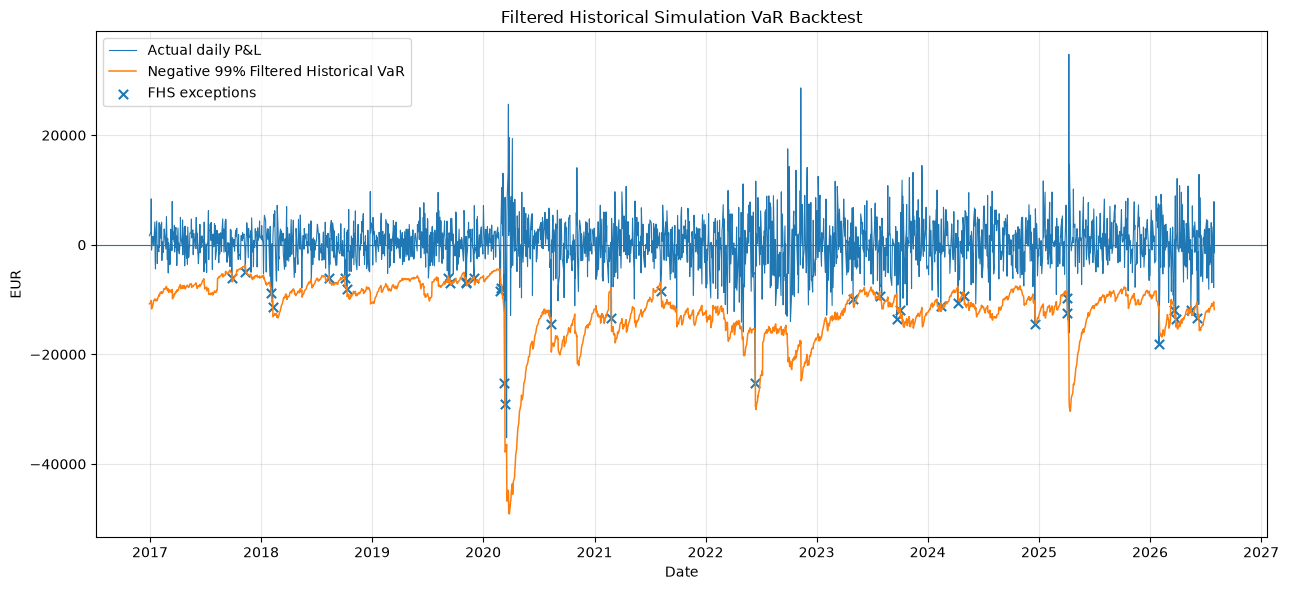

In [45]:
fig_fhs_backtest, ax = plt.subplots(
    figsize=(13, 6)
)

ax.plot(
    fhs_backtest_results.index,
    fhs_backtest_results[
        "actual_pnl_eur"
    ],
    linewidth=0.8,
    label="Actual daily P&L",
)

ax.plot(
    fhs_backtest_results.index,
    -fhs_backtest_results[
        "fhs_var_eur"
    ],
    linewidth=1.1,
    label="Negative 99% Filtered Historical VaR",
)

fhs_exception_dates = fhs_backtest_results[
    fhs_backtest_results[
        "fhs_exception"
    ]
]

ax.scatter(
    fhs_exception_dates.index,
    fhs_exception_dates[
        "actual_pnl_eur"
    ],
    marker="x",
    s=45,
    label="FHS exceptions",
)

ax.axhline(
    0,
    linewidth=0.8,
)

ax.set_title(
    "Filtered Historical Simulation VaR Backtest"
)
ax.set_xlabel("Date")
ax.set_ylabel("EUR")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
fhs_current_results.to_csv(
    TABLES_DIR / "filtered_historical_current_var_es.csv",
    index=False,
)

fhs_backtest_results.to_csv(
    TABLES_DIR / "filtered_historical_rolling_backtest.csv",
    index=True,
)

fhs_exception_summary.to_csv(
    TABLES_DIR / "filtered_historical_exception_summary.csv",
    index=False,
)

fig_fhs_distribution.savefig(
    CHARTS_DIR / "filtered_historical_scenario_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

fig_fhs_backtest.savefig(
    CHARTS_DIR / "filtered_historical_var_backtest.png",
    dpi=300,
    bbox_inches="tight",
)

print("Filtered Historical Simulation outputs saved.")

Filtered Historical Simulation outputs saved.


### Filtered Historical Simulation interpretation

The current 99% Filtered Historical Simulation VaR is approximately
EUR 11,504, while Expected Shortfall is approximately EUR 16,372.

The VaR estimate is below the two Student-t specifications, but the Expected
Shortfall estimate is the highest among the Day 3 models. This indicates that
the empirical standardized-residual distribution contains a small number of
particularly severe downside shocks.

The current specification uses 230 standardized residual scenarios. At the
99% confidence level, Expected Shortfall is based on only 2.3 effective tail
scenarios. The resulting tail-severity estimate is therefore sensitive to
individual extreme observations and should be interpreted cautiously.

Across 2,404 rolling forecasts, Filtered Historical Simulation produces
35 exceptions, corresponding to an exception rate of approximately 1.46%.
This is an improvement over the normal-distribution models, but it is weaker
than the static and EWMA Student-t specifications in terms of total exception
frequency.

Formal coverage and independence tests are required to determine whether the
empirical filtering procedure improves overall model validity.

In [47]:
fhs_kupiec = kupiec_unconditional_coverage_test(
    exceptions=fhs_backtest_results[
        "fhs_exception"
    ],
    confidence_level=CONFIDENCE_LEVEL,
)

fhs_independence = christoffersen_independence_test(
    exceptions=fhs_backtest_results[
        "fhs_exception"
    ]
)

fhs_conditional_coverage_lr = (
    fhs_kupiec["kupiec_lr_statistic"]
    + fhs_independence[
        "independence_lr_statistic"
    ]
)

fhs_conditional_coverage_p_value = chi2.sf(
    fhs_conditional_coverage_lr,
    df=2,
)

fhs_test_results = pd.DataFrame(
    {
        "model": [
            "Filtered Historical Simulation"
        ],
        "observations": [
            fhs_kupiec["observations"]
        ],
        "expected_exceptions": [
            fhs_kupiec["expected_exceptions"]
        ],
        "actual_exceptions": [
            fhs_kupiec["actual_exceptions"]
        ],
        "observed_exception_rate": [
            fhs_kupiec[
                "observed_probability"
            ]
        ],
        "kupiec_lr": [
            fhs_kupiec[
                "kupiec_lr_statistic"
            ]
        ],
        "kupiec_p_value": [
            fhs_kupiec[
                "kupiec_p_value"
            ]
        ],
        "reject_unconditional_coverage_at_5_percent": [
            fhs_kupiec[
                "reject_unconditional_coverage_at_5_percent"
            ]
        ],
        "probability_after_no_exception": [
            fhs_independence[
                "probability_after_no_exception"
            ]
        ],
        "probability_after_exception": [
            fhs_independence[
                "probability_after_exception"
            ]
        ],
        "independence_lr": [
            fhs_independence[
                "independence_lr_statistic"
            ]
        ],
        "independence_p_value": [
            fhs_independence[
                "independence_p_value"
            ]
        ],
        "reject_independence_at_5_percent": [
            fhs_independence[
                "reject_independence_at_5_percent"
            ]
        ],
        "conditional_coverage_lr": [
            fhs_conditional_coverage_lr
        ],
        "conditional_coverage_p_value": [
            fhs_conditional_coverage_p_value
        ],
        "reject_conditional_coverage_at_5_percent": [
            fhs_conditional_coverage_p_value
            < 0.05
        ],
    }
)

display(
    fhs_test_results.style.format(
        {
            "expected_exceptions": "{:.2f}",
            "observed_exception_rate": "{:.2%}",
            "kupiec_lr": "{:.4f}",
            "kupiec_p_value": "{:.6f}",
            "probability_after_no_exception": "{:.2%}",
            "probability_after_exception": "{:.2%}",
            "independence_lr": "{:.4f}",
            "independence_p_value": "{:.6f}",
            "conditional_coverage_lr": "{:.4f}",
            "conditional_coverage_p_value": "{:.6f}",
        }
    )
)

,model,observations,expected_exceptions,actual_exceptions,observed_exception_rate,kupiec_lr,kupiec_p_value,reject_unconditional_coverage_at_5_percent,probability_after_no_exception,probability_after_exception,independence_lr,independence_p_value,reject_independence_at_5_percent,conditional_coverage_lr,conditional_coverage_p_value,reject_conditional_coverage_at_5_percent
0,Filtered Historical Simulation,2404,24.04,35,1.46%,4.4246,0.035425,True,1.39%,5.71%,2.6189,0.105599,False,7.0435,0.029548,True


In [48]:
fhs_test_results.to_csv(
    TABLES_DIR
    / "filtered_historical_backtesting_tests.csv",
    index=False,
)

print(
    "Filtered Historical Simulation "
    "backtesting tests saved."
)

Filtered Historical Simulation backtesting tests saved.


### Filtered Historical Simulation backtesting interpretation

Filtered Historical Simulation produces 35 exceptions across 2,404 forecasts,
corresponding to an observed exception rate of approximately 1.46%.

The Kupiec p-value is 0.0354, so correct unconditional coverage is narrowly
rejected at the 5% significance level.

The probability of an exception following a non-exception is approximately
1.39%, while the probability following another exception is approximately
5.71%. The Christoffersen independence-test p-value is 0.1056, so exception
independence is not rejected.

The conditional-coverage p-value is approximately 0.0295. The model therefore
still fails overall conditional coverage, primarily because its total
exception frequency remains too high.

Compared with Weighted Historical Simulation and the Student-t models,
volatility filtering materially reduces exception clustering. However, the
250-day specification does not provide fully adequate coverage.

## 6. Filtered Historical Simulation sensitivity analysis

The baseline Filtered Historical Simulation specification uses a 250-day
lookback window and an EWMA decay factor of 0.94.

Model performance may depend materially on these choices:

- A lower decay factor reacts more quickly to recent volatility.
- A higher decay factor produces smoother volatility estimates.
- A longer lookback provides more empirical tail scenarios but may include
  observations from less relevant historical regimes.

The sensitivity analysis evaluates decay factors of 0.94, 0.97 and 0.99 using
250-day and 500-day lookback windows.

All specifications are compared over a common evaluation period beginning
after 500 observations. This prevents models with different lookback windows
from being ranked using different realised market periods.

## 6. Filtered Historical Simulation sensitivity analysis

The baseline Filtered Historical Simulation specification uses a 250-day
lookback window and an EWMA decay factor of 0.94.

Model performance may depend materially on these choices:

- A lower decay factor reacts more quickly to recent volatility.
- A higher decay factor produces smoother volatility estimates.
- A longer lookback provides more empirical tail scenarios but may include
  observations from less relevant historical regimes.

The sensitivity analysis evaluates decay factors of 0.94, 0.97 and 0.99 using
250-day and 500-day lookback windows.

All specifications are compared over a common evaluation period beginning
after 500 observations. This prevents models with different lookback windows
from being ranked using different realised market periods.

In [50]:
def run_filtered_historical_backtest(
    pnl_series: pd.Series,
    lookback_window: int,
    confidence_level: float,
    decay_factor: float,
    initialization_window: int = 20,
) -> pd.DataFrame:
    """
    Generate rolling Filtered Historical Simulation forecasts.
    """
    clean_pnl = (
        pd.Series(pnl_series)
        .dropna()
        .astype(float)
        .sort_index()
    )

    if lookback_window <= initialization_window + 30:
        raise ValueError(
            "The lookback window is too short."
        )

    if len(clean_pnl) <= lookback_window:
        raise ValueError(
            "The P&L series is shorter than the lookback window."
        )

    records = []

    for observation_number in range(
        lookback_window,
        len(clean_pnl),
    ):
        forecast_date = clean_pnl.index[
            observation_number
        ]

        estimation_sample = clean_pnl.iloc[
            observation_number - lookback_window:
            observation_number
        ]

        forecast_result, _ = (
            calculate_filtered_historical_var_es(
                pnl_series=estimation_sample,
                confidence_level=confidence_level,
                decay_factor=decay_factor,
                initialization_window=initialization_window,
            )
        )

        actual_pnl = float(
            clean_pnl.iloc[observation_number]
        )

        forecast_var = float(
            forecast_result["var_eur"]
        )

        records.append(
            {
                "date": forecast_date,
                "actual_pnl_eur": actual_pnl,
                "forecast_volatility_eur": (
                    forecast_result[
                        "forecast_volatility_eur"
                    ]
                ),
                "var_eur": forecast_var,
                "expected_shortfall_eur": (
                    forecast_result[
                        "expected_shortfall_eur"
                    ]
                ),
                "exception": (
                    actual_pnl < -forecast_var
                ),
            }
        )

    results = (
        pd.DataFrame(records)
        .set_index("date")
    )

    assert len(results) == len(clean_pnl) - lookback_window
    assert (results["var_eur"] > 0).all()

    assert np.all(
        results["expected_shortfall_eur"]
        >= results["var_eur"] - 1e-8
    )

    return results

In [51]:
FHS_SENSITIVITY_LOOKBACKS = [250, 500]
FHS_SENSITIVITY_LAMBDAS = [0.94, 0.97, 0.99]

fhs_sensitivity_backtests = {}

total_specifications = (
    len(FHS_SENSITIVITY_LOOKBACKS)
    * len(FHS_SENSITIVITY_LAMBDAS)
)

completed_specifications = 0

for lookback_window in FHS_SENSITIVITY_LOOKBACKS:
    for decay_factor in FHS_SENSITIVITY_LAMBDAS:
        specification_name = (
            f"FHS_{lookback_window}_"
            f"lambda_{decay_factor:.2f}"
        )

        print(
            f"Running {specification_name}..."
        )

        specification_results = (
            run_filtered_historical_backtest(
                pnl_series=portfolio_pnl,
                lookback_window=lookback_window,
                confidence_level=CONFIDENCE_LEVEL,
                decay_factor=decay_factor,
                initialization_window=20,
            )
        )

        fhs_sensitivity_backtests[
            specification_name
        ] = specification_results

        completed_specifications += 1

        print(
            f"Completed {completed_specifications} of "
            f"{total_specifications} specifications."
        )

Running FHS_250_lambda_0.94...
Completed 1 of 6 specifications.
Running FHS_250_lambda_0.97...
Completed 2 of 6 specifications.
Running FHS_250_lambda_0.99...
Completed 3 of 6 specifications.
Running FHS_500_lambda_0.94...
Completed 4 of 6 specifications.
Running FHS_500_lambda_0.97...
Completed 5 of 6 specifications.
Running FHS_500_lambda_0.99...
Completed 6 of 6 specifications.


In [52]:
MAXIMUM_SENSITIVITY_LOOKBACK = max(
    FHS_SENSITIVITY_LOOKBACKS
)

common_evaluation_start = portfolio_pnl.index[
    MAXIMUM_SENSITIVITY_LOOKBACK
]

common_evaluation_end = portfolio_pnl.index[-1]

print(
    f"Common evaluation period: "
    f"{common_evaluation_start.date()} to "
    f"{common_evaluation_end.date()}"
)

print(
    f"Common evaluation observations: "
    f"{len(portfolio_pnl) - MAXIMUM_SENSITIVITY_LOOKBACK:,}"
)

Common evaluation period: 2018-01-02 to 2026-07-31
Common evaluation observations: 2,154


In [53]:
def summarize_var_backtest(
    exceptions: pd.Series,
    confidence_level: float,
) -> dict:
    """
    Combine Kupiec, independence and conditional-coverage results.
    """
    kupiec_result = (
        kupiec_unconditional_coverage_test(
            exceptions=exceptions,
            confidence_level=confidence_level,
        )
    )

    independence_result = (
        christoffersen_independence_test(
            exceptions=exceptions
        )
    )

    conditional_coverage_lr = (
        kupiec_result["kupiec_lr_statistic"]
        + independence_result[
            "independence_lr_statistic"
        ]
    )

    conditional_coverage_p_value = chi2.sf(
        conditional_coverage_lr,
        df=2,
    )

    return {
        "observations": kupiec_result[
            "observations"
        ],
        "expected_exceptions": kupiec_result[
            "expected_exceptions"
        ],
        "actual_exceptions": kupiec_result[
            "actual_exceptions"
        ],
        "observed_exception_rate": kupiec_result[
            "observed_probability"
        ],
        "exception_rate_gap": (
            kupiec_result["observed_probability"]
            - (1 - confidence_level)
        ),
        "kupiec_lr": kupiec_result[
            "kupiec_lr_statistic"
        ],
        "kupiec_p_value": kupiec_result[
            "kupiec_p_value"
        ],
        "passes_unconditional_coverage": (
            kupiec_result["kupiec_p_value"]
            >= 0.05
        ),
        "probability_after_no_exception": (
            independence_result[
                "probability_after_no_exception"
            ]
        ),
        "probability_after_exception": (
            independence_result[
                "probability_after_exception"
            ]
        ),
        "independence_lr": independence_result[
            "independence_lr_statistic"
        ],
        "independence_p_value": (
            independence_result[
                "independence_p_value"
            ]
        ),
        "passes_independence": (
            independence_result[
                "independence_p_value"
            ]
            >= 0.05
        ),
        "conditional_coverage_lr": float(
            conditional_coverage_lr
        ),
        "conditional_coverage_p_value": float(
            conditional_coverage_p_value
        ),
        "passes_conditional_coverage": (
            conditional_coverage_p_value
            >= 0.05
        ),
    }

In [54]:
fhs_sensitivity_rows = []

for lookback_window in FHS_SENSITIVITY_LOOKBACKS:
    for decay_factor in FHS_SENSITIVITY_LAMBDAS:
        specification_name = (
            f"FHS_{lookback_window}_"
            f"lambda_{decay_factor:.2f}"
        )

        complete_backtest = (
            fhs_sensitivity_backtests[
                specification_name
            ]
        )

        common_backtest = complete_backtest.loc[
            common_evaluation_start:
        ]

        validation_result = summarize_var_backtest(
            exceptions=common_backtest["exception"],
            confidence_level=CONFIDENCE_LEVEL,
        )

        current_result, _ = (
            calculate_filtered_historical_var_es(
                pnl_series=portfolio_pnl.iloc[
                    -lookback_window:
                ],
                confidence_level=CONFIDENCE_LEVEL,
                decay_factor=decay_factor,
                initialization_window=20,
            )
        )

        fhs_sensitivity_rows.append(
            {
                "specification": specification_name,
                "lookback_window": lookback_window,
                "decay_factor": decay_factor,
                "residual_scenarios": (
                    current_result[
                        "residual_observations"
                    ]
                ),
                "effective_es_tail_scenarios": (
                    current_result[
                        "effective_tail_scenarios"
                    ]
                ),
                "current_var_eur": (
                    current_result["var_eur"]
                ),
                "current_expected_shortfall_eur": (
                    current_result[
                        "expected_shortfall_eur"
                    ]
                ),
                **validation_result,
            }
        )

fhs_sensitivity_results = pd.DataFrame(
    fhs_sensitivity_rows
)

In [55]:
fhs_sensitivity_results[
    "absolute_exception_rate_gap"
] = (
    fhs_sensitivity_results[
        "exception_rate_gap"
    ].abs()
)

fhs_sensitivity_results[
    "frequency_rank"
] = (
    fhs_sensitivity_results[
        "absolute_exception_rate_gap"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

fhs_sensitivity_results[
    "independence_rank"
] = (
    fhs_sensitivity_results[
        "independence_p_value"
    ]
    .rank(
        method="min",
        ascending=False,
    )
    .astype(int)
)

fhs_sensitivity_results[
    "overall_diagnostic_rank"
] = (
    fhs_sensitivity_results[
        "conditional_coverage_lr"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

fhs_sensitivity_results = (
    fhs_sensitivity_results
    .sort_values(
        [
            "overall_diagnostic_rank",
            "frequency_rank",
        ]
    )
    .reset_index(drop=True)
)

display(
    fhs_sensitivity_results.style.format(
        {
            "decay_factor": "{:.2f}",
            "effective_es_tail_scenarios": "{:.2f}",
            "current_var_eur": "EUR {:,.2f}",
            "current_expected_shortfall_eur": "EUR {:,.2f}",
            "expected_exceptions": "{:.2f}",
            "observed_exception_rate": "{:.2%}",
            "exception_rate_gap": "{:+.2%}",
            "absolute_exception_rate_gap": "{:.2%}",
            "kupiec_lr": "{:.4f}",
            "kupiec_p_value": "{:.6f}",
            "probability_after_no_exception": "{:.2%}",
            "probability_after_exception": "{:.2%}",
            "independence_lr": "{:.4f}",
            "independence_p_value": "{:.6f}",
            "conditional_coverage_lr": "{:.4f}",
            "conditional_coverage_p_value": "{:.6f}",
        }
    )
)

,specification,lookback_window,decay_factor,residual_scenarios,effective_es_tail_scenarios,current_var_eur,current_expected_shortfall_eur,observations,expected_exceptions,actual_exceptions,observed_exception_rate,exception_rate_gap,kupiec_lr,kupiec_p_value,passes_unconditional_coverage,probability_after_no_exception,probability_after_exception,independence_lr,independence_p_value,passes_independence,conditional_coverage_lr,conditional_coverage_p_value,passes_conditional_coverage,absolute_exception_rate_gap,frequency_rank,independence_rank,overall_diagnostic_rank
0,FHS_500_lambda_0.94,500,0.94,480,4.80,"EUR 12,630.43","EUR 15,699.79",2154,21.54,23,1.07%,+0.07%,0.0978,0.754490,True,0.99%,8.70%,5.1577,0.023143,False,5.2555,0.072241,True,0.07%,1,2,1
1,FHS_250_lambda_0.94,250,0.94,230,2.30,"EUR 11,504.04","EUR 16,371.68",2154,21.54,33,1.53%,+0.53%,5.2970,0.021362,False,1.46%,6.06%,2.6513,0.103468,True,7.9483,0.018795,False,0.53%,5,1,2
2,FHS_500_lambda_0.99,500,0.99,480,4.80,"EUR 14,135.90","EUR 17,220.47",2154,21.54,29,1.35%,+0.35%,2.3544,0.124929,True,1.18%,13.79%,12.3497,0.000441,False,14.7041,0.000641,False,0.35%,3,5,3
3,FHS_250_lambda_0.97,250,0.97,230,2.30,"EUR 12,446.28","EUR 17,355.85",2154,21.54,32,1.49%,+0.49%,4.4641,0.034613,False,1.32%,12.50%,10.8119,0.001009,False,15.2760,0.000482,False,0.49%,4,4,4
4,FHS_500_lambda_0.97,500,0.97,480,4.80,"EUR 13,435.39","EUR 16,895.15",2154,21.54,25,1.16%,+0.16%,0.5338,0.465003,True,0.99%,16.00%,14.7466,0.000123,False,15.2805,0.000481,False,0.16%,2,6,5
5,FHS_250_lambda_0.99,250,0.99,230,2.30,"EUR 13,838.17","EUR 18,806.89",2154,21.54,38,1.76%,+0.76%,10.3506,0.001294,False,1.61%,10.53%,8.2450,0.004086,False,18.5956,0.000092,False,0.76%,6,3,6


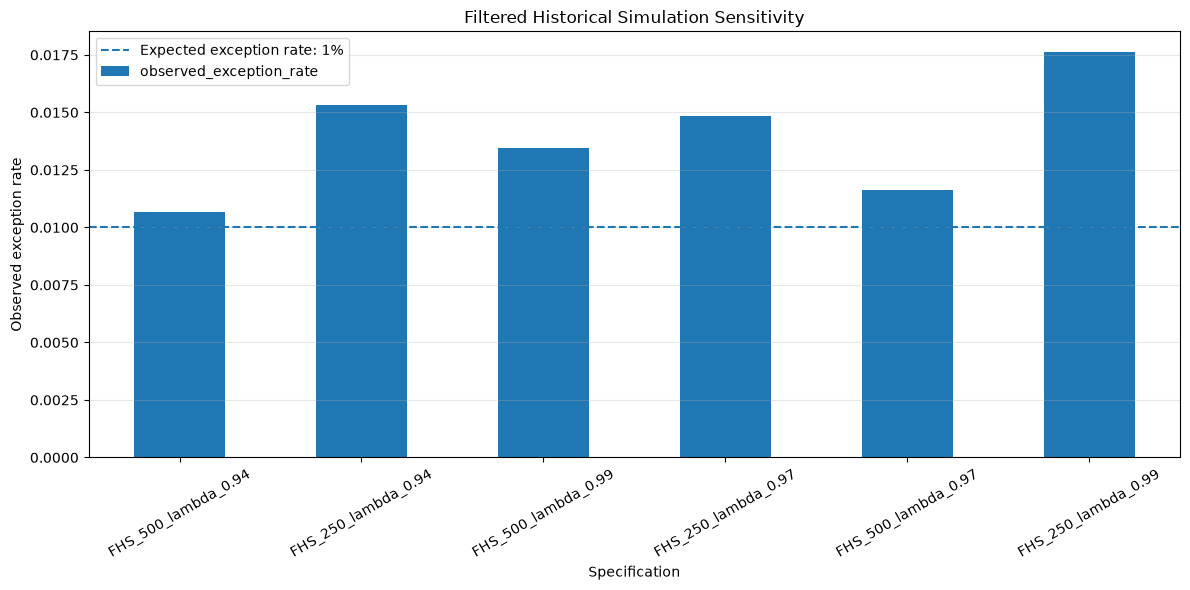

In [56]:
fig_fhs_sensitivity, ax = plt.subplots(
    figsize=(12, 6)
)

plot_data = (
    fhs_sensitivity_results
    .set_index("specification")
    ["observed_exception_rate"]
)

plot_data.plot(
    kind="bar",
    ax=ax,
)

ax.axhline(
    TAIL_PROBABILITY,
    linestyle="--",
    linewidth=1.5,
    label="Expected exception rate: 1%",
)

ax.set_title(
    "Filtered Historical Simulation Sensitivity"
)
ax.set_xlabel("Specification")
ax.set_ylabel("Observed exception rate")
ax.tick_params(
    axis="x",
    rotation=30,
)
ax.legend()
ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

In [57]:
fhs_sensitivity_forecast_frames = []

for specification_name, results in (
    fhs_sensitivity_backtests.items()
):
    common_results = results.loc[
        common_evaluation_start:
    ].copy()

    common_results[
        "specification"
    ] = specification_name

    fhs_sensitivity_forecast_frames.append(
        common_results.reset_index()
    )

fhs_sensitivity_forecasts = pd.concat(
    fhs_sensitivity_forecast_frames,
    ignore_index=True,
)

fhs_sensitivity_results.to_csv(
    TABLES_DIR
    / "filtered_historical_sensitivity_results.csv",
    index=False,
)

fhs_sensitivity_forecasts.to_csv(
    TABLES_DIR
    / "filtered_historical_sensitivity_forecasts.csv",
    index=False,
)

fig_fhs_sensitivity.savefig(
    CHARTS_DIR
    / "filtered_historical_sensitivity.png",
    dpi=300,
    bbox_inches="tight",
)

print("FHS sensitivity outputs saved.")

FHS sensitivity outputs saved.


### Filtered Historical Simulation sensitivity interpretation

The sensitivity analysis identifies the 500-day Filtered Historical Simulation
model with an EWMA decay factor of 0.94 as the strongest specification.

Over the common 2,154-day evaluation period, the model produces 23 exceptions
compared with approximately 21.54 expected exceptions. Its observed exception
rate of 1.07% is very close to the theoretical 1% rate.

The Kupiec p-value is 0.7545, so unconditional coverage is not rejected.
Although the independence p-value of 0.0231 indicates that exceptions remain
clustered, the combined conditional-coverage p-value is 0.0722. Conditional
coverage is therefore not rejected at the 5% significance level.

The combined test can pass even when the independence test fails because the
two tests use different degrees of freedom and critical values.

The 500-day window also increases the number of standardized residual scenarios
from 230 to 480. Consequently, the 99% Expected Shortfall estimate uses 4.8
effective tail scenarios rather than 2.3, reducing sensitivity to individual
extreme observations.

The preferred specification is therefore FHS with a 500-day lookback and a
0.94 decay factor. Nevertheless, the rejected independence test remains an
important model limitation.

In [58]:
PREFERRED_FHS_SPECIFICATION = "FHS_500_lambda_0.94"

preferred_fhs_backtest = (
    fhs_sensitivity_backtests[
        PREFERRED_FHS_SPECIFICATION
    ]
    .loc[common_evaluation_start:]
    .copy()
)

preferred_fhs_current = (
    fhs_sensitivity_results.loc[
        fhs_sensitivity_results["specification"]
        == PREFERRED_FHS_SPECIFICATION
    ]
    .iloc[0]
)

print(
    f"Preferred FHS model: "
    f"{PREFERRED_FHS_SPECIFICATION}"
)

print(
    f"Common-period forecasts: "
    f"{len(preferred_fhs_backtest):,}"
)

print(
    f"Current VaR: "
    f"EUR {preferred_fhs_current['current_var_eur']:,.2f}"
)

print(
    f"Current ES: "
    f"EUR "
    f"{preferred_fhs_current['current_expected_shortfall_eur']:,.2f}"
)

Preferred FHS model: FHS_500_lambda_0.94
Common-period forecasts: 2,154
Current VaR: EUR 12,630.43
Current ES: EUR 15,699.79


In [59]:
def load_backtest_table(filename: str) -> pd.DataFrame:
    """Load a saved rolling-backtest CSV with a datetime index."""
    path = TABLES_DIR / filename

    if not path.exists():
        raise FileNotFoundError(
            f"{filename} was not found in {TABLES_DIR}."
        )

    table = pd.read_csv(path)

    date_candidates = [
        column
        for column in table.columns
        if column.lower() in {"date", "index", "unnamed: 0"}
    ]

    if not date_candidates:
        date_column = table.columns[0]
    else:
        date_column = date_candidates[0]

    table[date_column] = pd.to_datetime(
        table[date_column]
    )

    table = (
        table
        .set_index(date_column)
        .sort_index()
    )

    table.index.name = "date"

    return table


day_1_backtest = load_backtest_table(
    "rolling_var_backtest.csv"
)

ewma_normal_backtest = load_backtest_table(
    "ewma_rolling_backtest.csv"
)

weighted_historical_backtest = load_backtest_table(
    "weighted_historical_backtest.csv"
)

monte_carlo_backtest = load_backtest_table(
    "monte_carlo_rolling_backtest.csv"
)

print("Day 1 columns:")
print(day_1_backtest.columns.tolist())

print("\nEWMA columns:")
print(ewma_normal_backtest.columns.tolist())

print("\nWeighted Historical columns:")
print(weighted_historical_backtest.columns.tolist())

print("\nMonte Carlo columns:")
print(monte_carlo_backtest.columns.tolist())

Day 1 columns:
['actual_pnl_eur', 'historical_var_eur', 'parametric_var_eur', 'historical_exception', 'parametric_exception']

EWMA columns:
['actual_pnl_eur', 'ewma_volatility_eur', 'ewma_var_eur', 'ewma_exception']

Weighted Historical columns:
['actual_pnl_eur', 'whs_var_eur', 'whs_es_eur', 'whs_exception']

Monte Carlo columns:
['actual_pnl_eur', 'mc_volatility_eur', 'mc_var_eur', 'mc_es_eur', 'mc_exception']


In [60]:
def convert_to_boolean(series: pd.Series) -> pd.Series:
    """Convert stored Boolean or text exception indicators to Boolean."""
    if pd.api.types.is_bool_dtype(series):
        return series.astype(bool)

    if pd.api.types.is_numeric_dtype(series):
        return series.astype(int).astype(bool)

    converted = (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map(
            {
                "true": True,
                "false": False,
                "1": True,
                "0": False,
            }
        )
    )

    if converted.isna().any():
        raise ValueError(
            f"Unable to convert {series.name} to Boolean."
        )

    return converted.astype(bool)


def find_exception_series(
    table: pd.DataFrame,
    model_tokens: list[str],
    fallback_columns: list[str],
) -> pd.Series:
    """Locate the relevant exception column in a backtest table."""
    lower_columns = {
        column: column.lower()
        for column in table.columns
    }

    for column, lower_column in lower_columns.items():
        if (
            "exception" in lower_column
            and all(
                token.lower() in lower_column
                for token in model_tokens
            )
        ):
            return convert_to_boolean(
                table[column]
            )

    for column in fallback_columns:
        if column in table.columns:
            return convert_to_boolean(
                table[column]
            )

    raise KeyError(
        "Could not find the required exception column. "
        f"Available columns: {table.columns.tolist()}"
    )

In [61]:
model_exception_series = {
    "Historical Simulation": find_exception_series(
        table=day_1_backtest,
        model_tokens=["historical"],
        fallback_columns=[
            "historical_exception",
            "historical_var_exception",
            "hs_exception",
        ],
    ),
    "Parametric Normal": find_exception_series(
        table=day_1_backtest,
        model_tokens=["parametric"],
        fallback_columns=[
            "parametric_exception",
            "parametric_var_exception",
            "normal_exception",
        ],
    ),
    "EWMA Parametric Normal": find_exception_series(
        table=ewma_normal_backtest,
        model_tokens=["ewma"],
        fallback_columns=[
            "ewma_exception",
        ],
    ),
    "Weighted Historical Simulation": find_exception_series(
        table=weighted_historical_backtest,
        model_tokens=["whs"],
        fallback_columns=[
            "whs_exception",
        ],
    ),
    "Monte Carlo Normal": find_exception_series(
        table=monte_carlo_backtest,
        model_tokens=["mc"],
        fallback_columns=[
            "mc_exception",
        ],
    ),
    "Student-t Parametric": convert_to_boolean(
        student_t_backtest_results[
            "student_t_exception"
        ]
    ),
    "EWMA Student-t": convert_to_boolean(
        ewma_t_backtest_results[
            "ewma_t_exception"
        ]
    ),
    "Filtered Historical Simulation (500, 0.94)": (
        convert_to_boolean(
            preferred_fhs_backtest["exception"]
        )
    ),
}

for model, exception_series in model_exception_series.items():
    print(
        f"{model}: "
        f"{len(exception_series):,} available forecasts"
    )

Historical Simulation: 2,404 available forecasts
Parametric Normal: 2,404 available forecasts
EWMA Parametric Normal: 2,404 available forecasts
Weighted Historical Simulation: 2,404 available forecasts
Monte Carlo Normal: 2,404 available forecasts
Student-t Parametric: 2,404 available forecasts
EWMA Student-t: 2,404 available forecasts
Filtered Historical Simulation (500, 0.94): 2,154 available forecasts


In [62]:
common_model_index = preferred_fhs_backtest.index

for exception_series in model_exception_series.values():
    common_model_index = (
        common_model_index.intersection(
            exception_series.index
        )
    )

common_model_index = common_model_index.sort_values()

print(
    f"Final common-period observations: "
    f"{len(common_model_index):,}"
)

print(
    f"Period: {common_model_index.min().date()} "
    f"to {common_model_index.max().date()}"
)

assert len(common_model_index) == 2_154

Final common-period observations: 2,154
Period: 2018-01-02 to 2026-07-31


In [63]:
day_3_final_rows = []

for model, exception_series in model_exception_series.items():
    aligned_exceptions = exception_series.loc[
        common_model_index
    ]

    validation_result = summarize_var_backtest(
        exceptions=aligned_exceptions,
        confidence_level=CONFIDENCE_LEVEL,
    )

    day_3_final_rows.append(
        {
            "model": model,
            **validation_result,
        }
    )

day_3_final_validation = pd.DataFrame(
    day_3_final_rows
)

day_3_final_validation[
    "absolute_exception_rate_gap"
] = (
    day_3_final_validation[
        "exception_rate_gap"
    ].abs()
)

day_3_final_validation[
    "frequency_rank"
] = (
    day_3_final_validation[
        "absolute_exception_rate_gap"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

day_3_final_validation[
    "independence_rank"
] = (
    day_3_final_validation[
        "independence_p_value"
    ]
    .rank(
        method="min",
        ascending=False,
    )
    .astype(int)
)

day_3_final_validation[
    "overall_diagnostic_rank"
] = (
    day_3_final_validation[
        "conditional_coverage_lr"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

day_3_final_validation = (
    day_3_final_validation
    .sort_values(
        [
            "overall_diagnostic_rank",
            "frequency_rank",
        ]
    )
    .reset_index(drop=True)
)

display(
    day_3_final_validation.style.format(
        {
            "expected_exceptions": "{:.2f}",
            "observed_exception_rate": "{:.2%}",
            "exception_rate_gap": "{:+.2%}",
            "absolute_exception_rate_gap": "{:.2%}",
            "kupiec_lr": "{:.4f}",
            "kupiec_p_value": "{:.6f}",
            "probability_after_no_exception": "{:.2%}",
            "probability_after_exception": "{:.2%}",
            "independence_lr": "{:.4f}",
            "independence_p_value": "{:.6f}",
            "conditional_coverage_lr": "{:.4f}",
            "conditional_coverage_p_value": "{:.6f}",
        }
    )
)

,model,observations,expected_exceptions,actual_exceptions,observed_exception_rate,exception_rate_gap,kupiec_lr,kupiec_p_value,passes_unconditional_coverage,probability_after_no_exception,probability_after_exception,independence_lr,independence_p_value,passes_independence,conditional_coverage_lr,conditional_coverage_p_value,passes_conditional_coverage,absolute_exception_rate_gap,frequency_rank,independence_rank,overall_diagnostic_rank
0,"Filtered Historical Simulation (500, 0.94)",2154,21.54,23,1.07%,+0.07%,0.0978,0.754490,True,0.99%,8.70%,5.1577,0.023143,False,5.2555,0.072241,True,0.07%,1,2,1
1,EWMA Student-t,2154,21.54,30,1.39%,+0.39%,2.9907,0.083741,True,1.27%,10.00%,7.1287,0.007586,False,10.1194,0.006347,False,0.39%,2,4,2
2,Student-t Parametric,2154,21.54,31,1.44%,+0.44%,3.6947,0.054585,True,1.32%,9.68%,6.7666,0.009288,False,10.4613,0.005350,False,0.44%,3,3,3
3,Weighted Historical Simulation,2154,21.54,34,1.58%,+0.58%,6.1915,0.012837,False,1.42%,11.76%,9.8880,0.001664,False,16.0795,0.000322,False,0.58%,4,8,4
4,Historical Simulation,2154,21.54,41,1.90%,+0.90%,14.0383,0.000179,False,1.75%,9.76%,7.1664,0.007428,False,21.2046,0.000025,False,0.90%,5,5,5
5,EWMA Parametric Normal,2154,21.54,44,2.04%,+1.04%,18.1739,0.000020,False,1.94%,6.82%,3.2379,0.071955,True,21.4117,0.000022,False,1.04%,6,1,6
6,Monte Carlo Normal,2154,21.54,45,2.09%,+1.09%,19.6466,0.000009,False,1.90%,11.11%,9.3685,0.002207,False,29.0151,0.000001,False,1.09%,7,7,7
7,Parametric Normal,2154,21.54,46,2.14%,+1.14%,21.1648,0.000004,False,1.95%,10.87%,8.9805,0.002729,False,30.1452,0.000000,False,1.14%,8,6,8


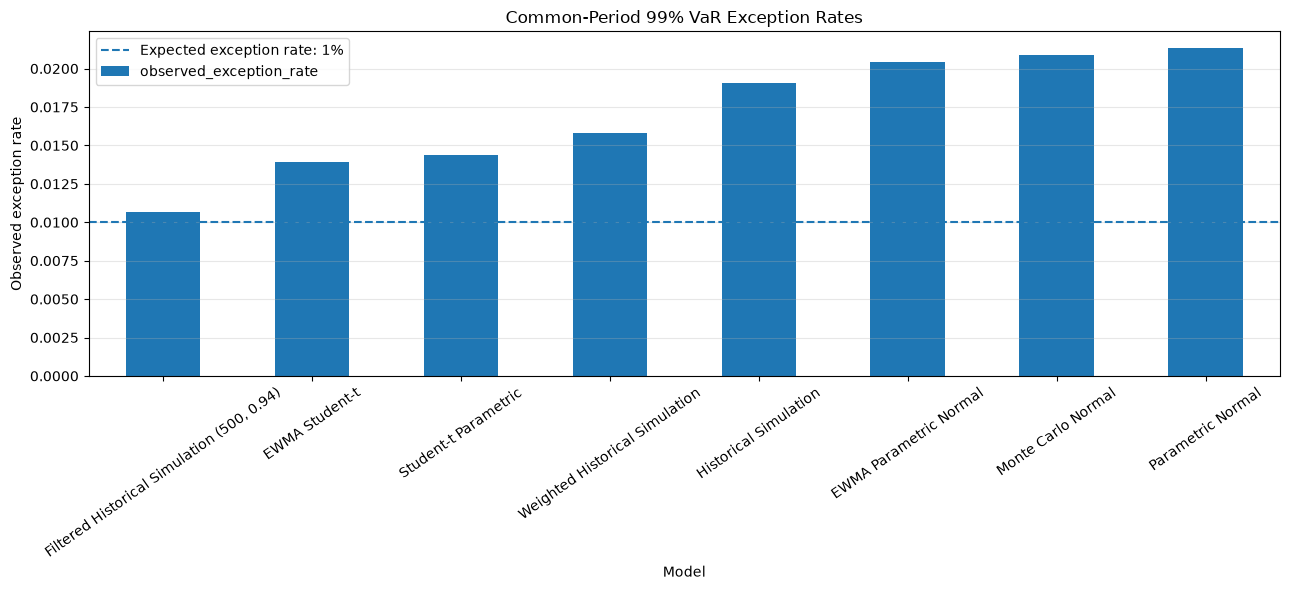

In [64]:
fig_day_3_exception_rates, ax = plt.subplots(
    figsize=(13, 6)
)

(
    day_3_final_validation
    .set_index("model")
    ["observed_exception_rate"]
    .plot(
        kind="bar",
        ax=ax,
    )
)

ax.axhline(
    TAIL_PROBABILITY,
    linestyle="--",
    linewidth=1.5,
    label="Expected exception rate: 1%",
)

ax.set_title(
    "Common-Period 99% VaR Exception Rates"
)
ax.set_xlabel("Model")
ax.set_ylabel("Observed exception rate")
ax.tick_params(
    axis="x",
    rotation=35,
)
ax.legend()
ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

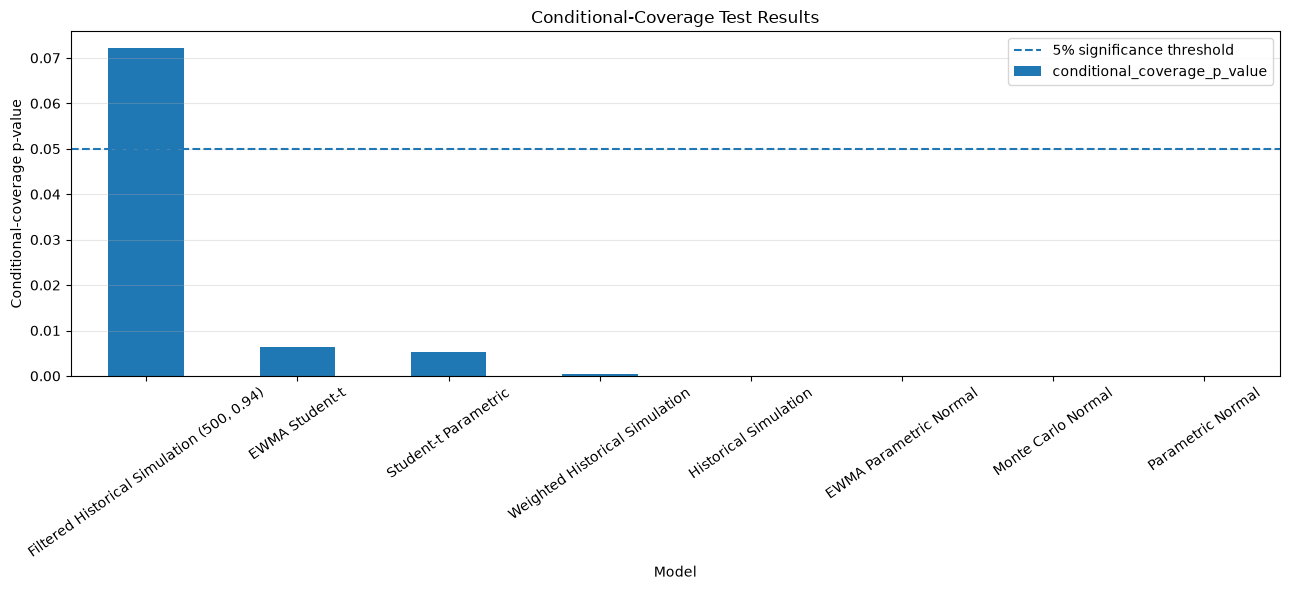

In [65]:
fig_day_3_conditional_coverage, ax = plt.subplots(
    figsize=(13, 6)
)

(
    day_3_final_validation
    .set_index("model")
    ["conditional_coverage_p_value"]
    .plot(
        kind="bar",
        ax=ax,
    )
)

ax.axhline(
    0.05,
    linestyle="--",
    linewidth=1.5,
    label="5% significance threshold",
)

ax.set_title(
    "Conditional-Coverage Test Results"
)
ax.set_xlabel("Model")
ax.set_ylabel("Conditional-coverage p-value")
ax.tick_params(
    axis="x",
    rotation=35,
)
ax.legend()
ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

In [66]:
day_3_final_validation.to_csv(
    TABLES_DIR
    / "day_3_all_model_common_period_validation.csv",
    index=False,
)

fig_day_3_exception_rates.savefig(
    CHARTS_DIR
    / "day_3_common_period_exception_rates.png",
    dpi=300,
    bbox_inches="tight",
)

fig_day_3_conditional_coverage.savefig(
    CHARTS_DIR
    / "day_3_conditional_coverage_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

print("Final Day 3 model-comparison outputs saved.")

Final Day 3 model-comparison outputs saved.


## 7. Day 3 conclusions

Day 3 investigated whether heavy-tailed distributions and volatility filtering
improve one-day 99% VaR calibration.

The portfolio P&L distribution is materially non-normal. The full sample has
substantial excess kurtosis, while the most recent 250-day window retains
negative skewness and heavy tails. These findings explain why the normal-based
models systematically underestimate portfolio risk.

The static Student-t model substantially improves exception frequency. Over
the common evaluation period, it produces 31 exceptions compared with 21.54
expected and passes the Kupiec unconditional-coverage test. However, its
exceptions remain clustered, causing it to fail independence and conditional
coverage.

EWMA Student-t also passes unconditional coverage but does not materially
improve exception clustering. This shows that faster volatility adjustment
alone does not fully eliminate stressed-period dependence.

The preferred model is Filtered Historical Simulation with a 500-day lookback
window and an EWMA decay factor of 0.94. It produces 23 exceptions, an observed
exception rate of 1.07%, and passes both unconditional and combined conditional
coverage at the 5% significance level.

The preferred FHS model nevertheless fails the standalone independence test.
Its exceptions remain more likely immediately after another exception.
Accordingly, it should be described as the strongest candidate model rather
than a flawless or definitively validated model.

The sensitivity analysis also demonstrates that model design choices matter.
The longer 500-day window provides more empirical tail scenarios, while the
0.94 decay factor reacts more effectively to volatility changes than the
slower 0.97 and 0.99 specifications.

Overall, the results show that combining time-varying volatility with an
empirical, non-normal shock distribution provides the most effective risk
forecast within the current model set.

A remaining methodological limitation is that the preferred parameters were
selected using the same historical period used for model comparison. Future
validation should assess the selected specification on an untouched holdout
period or through nested rolling model selection.